In [1]:
#read the excel file into a pandas dataframe
import pandas as pd
df_youth = pd.read_excel(r"C:\Users\User\Desktop\youth unemployement\youth_data_cleaned_analyzed.xlsx")


In [5]:
import pandas as pd



# Display all feature/column names
print("Number of features:", len(df_youth.columns))
print("\nFeature names:\n")

for i, column in enumerate(df_youth.columns, start=1):
    print(f"{i}. {column}")

Number of features: 109

Feature names:

1. youth_id
2. education_level
3. field_of_study
4. current_status
5. job_search_duration
6. applications_3m
7. job_opportunity_source
8. job_search_barriers
9. biggest_difficulty
10. difficult_job_search_stage
11. application_outcome
12. experience_requirement
13. importance_connections
14. needed_connection
15. education_job_preparation
16. missing_skills
17. entry_level_experience
18. interview_without_offer
19. interview_difficulties
20. rejection_effect
21. employer_feedback
22. security_impact
23. job_acceptance_barriers
24. low_salary_response
25. modern_work_access
26. work_abroad_preference
27. reasons_work_abroad
28. employment_support
29. most_valuable_service
30. needed_systemic_change
31. job_opportunity_source__directly_from_employers
32. job_opportunity_source__friends_or_family
33. job_opportunity_source__linkedin_or_professional_platforms
34. job_opportunity_source__ngo_or_community_organization
35. job_opportunity_source__onlin

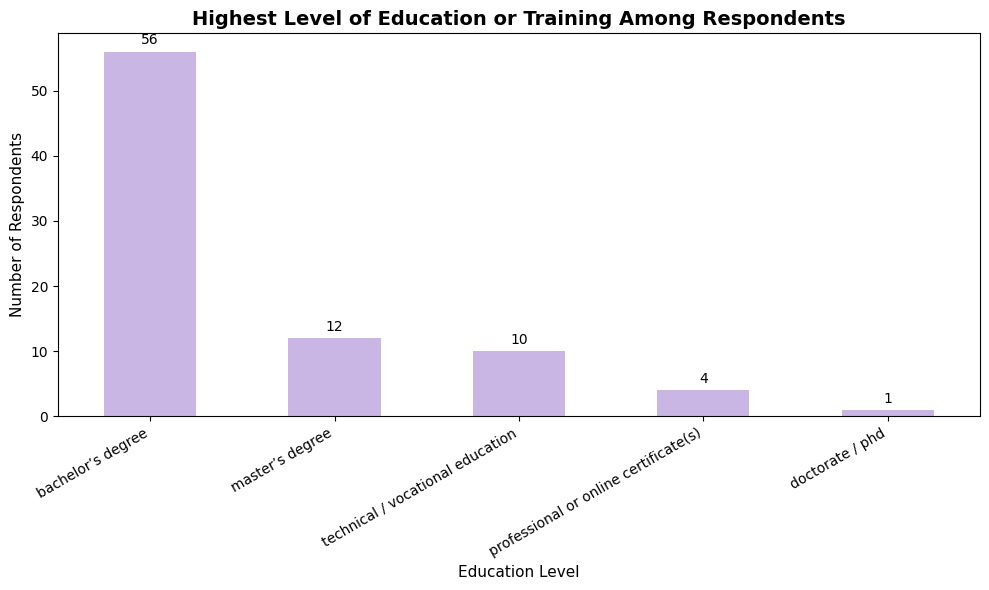

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

# Count education levels
education_counts = df_youth["education_level"].value_counts()

# Create chart
plt.figure(figsize=(10, 6))

ax = education_counts.plot(
    kind="bar",
    color="#C9B6E4"   # Light purple
)

plt.title(
    "Highest Level of Education or Training Among Respondents",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Education Level", fontsize=11)
plt.ylabel("Number of Respondents", fontsize=11)

plt.xticks(rotation=30, ha="right")

# Add values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=10
    )

plt.tight_layout()

# Save for Typst
plt.savefig(
    "figures/youth_education.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

                              Count  Percentage
field_department                               
Business & Management            17        20.5
Other                            17        20.5
Computing, Data & IT             13        15.7
Engineering                      11        13.3
Health & Medical Sciences        10        12.0
Arts, Design & Architecture       8         9.6
Social Sciences & Psychology      7         8.4


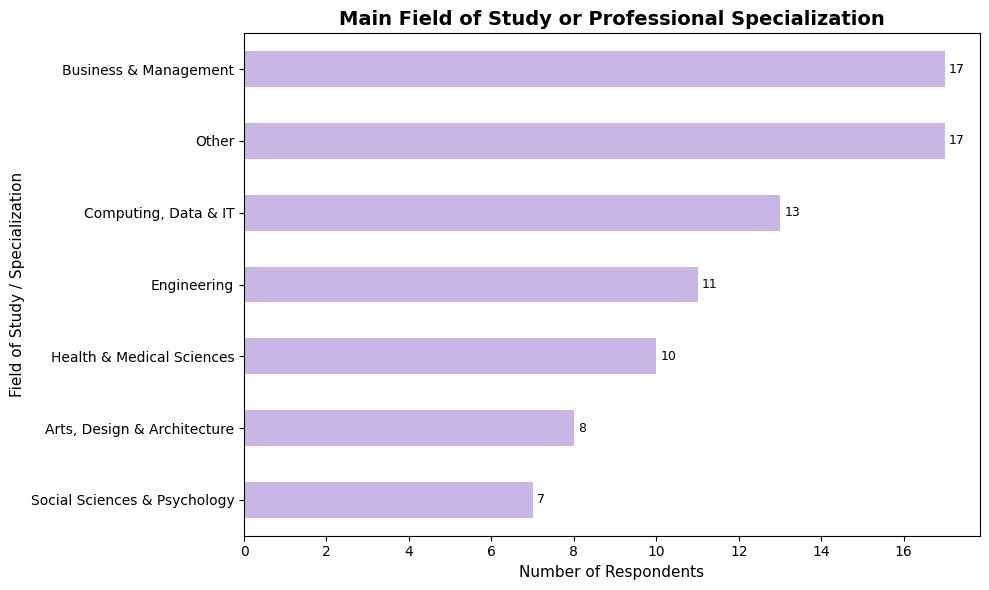

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

# Replace this with the actual column name for Q2 if different
field_col = "field_department"

# Clean responses
fields = (
    df_youth[field_col]
    .dropna()
    .astype(str)
    .str.strip()
)

# Remove empty responses
fields = fields[fields != ""]

# Count fields
field_counts = fields.value_counts()

# Display frequency table
field_summary = pd.DataFrame({
    "Count": field_counts,
    "Percentage": (field_counts / len(fields) * 100).round(1)
})

print(field_summary)

# Keep all fields, ordered from highest to lowest
field_counts = field_counts.sort_values(ascending=True)

# Create horizontal bar chart
plt.figure(figsize=(10, max(6, len(field_counts) * 0.4)))

ax = field_counts.plot(
    kind="barh",
    color="#C9B6E4"   # Light purple
)

plt.title(
    "Main Field of Study or Professional Specialization",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Respondents", fontsize=11)
plt.ylabel("Field of Study / Specialization", fontsize=11)

# Add values at the end of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=9
    )

plt.tight_layout()

# Save figure for Typst
plt.savefig(
    "figures/youth_field.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

                                                    Count  Percentage
current_status                                                       
i am currently unemployed and actively looking ...     49        59.0
i earn income through freelancing, temporary, i...     11        13.3
i am currently unemployed but not actively look...      9        10.8
i am working, but my current work does not prov...      8         9.6
other                                                   6         7.2


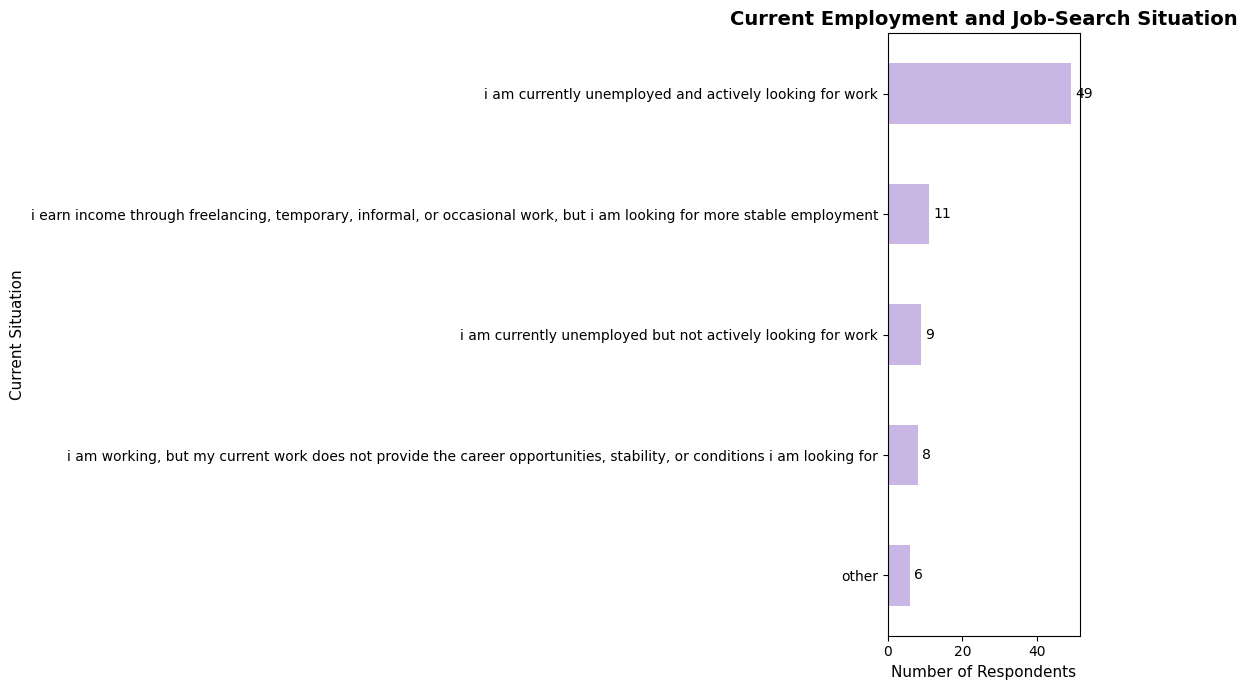

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

# Count current employment situations
situation_counts = (
    df_youth["current_status"]
    .dropna()
    .value_counts()
)

# Calculate percentages
situation_summary = pd.DataFrame({
    "Count": situation_counts,
    "Percentage": (
        situation_counts / situation_counts.sum() * 100
    ).round(1)
})

print(situation_summary)

# Create horizontal bar chart
plt.figure(figsize=(11, 7))

ax = situation_counts.sort_values(ascending=True).plot(
    kind="barh",
    color="#C9B6E4"
)

plt.title(
    "Current Employment and Job-Search Situation",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Respondents", fontsize=11)
plt.ylabel("Current Situation", fontsize=11)

# Add count labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=10
    )

plt.tight_layout()

# Save for Typst
plt.savefig(
    "figures/youth_current_situation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

                     Count  Percentage
job_search_duration                   
less than 3 months      19        27.5
3–6 months              13        18.8
6–12 months             16        23.2
more than 1 year        13        18.8
more than 2 years        8        11.6


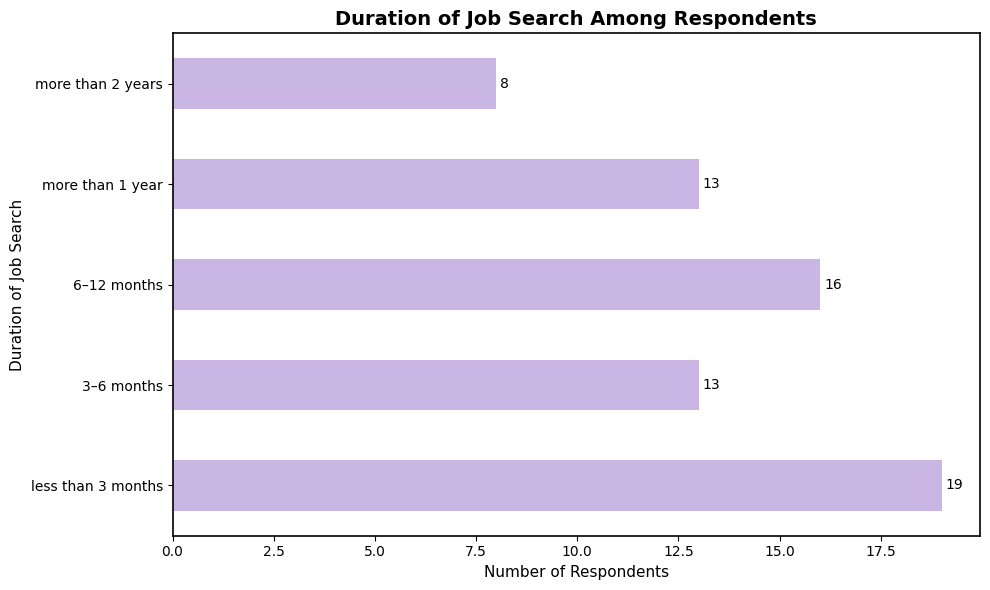

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

# Count job-search duration
duration_counts = (
    df_youth["job_search_duration"]
    .dropna()
    .value_counts()
)

# Define the logical order of categories
duration_order = [
    "less than 3 months",
    "3–6 months",
    "6–12 months",
    "more than 1 year",
    "more than 2 years",
    "not currently looking"
]

# Keep only categories that actually exist in the data
duration_order = [
    x for x in duration_order
    if x in duration_counts.index
]

duration_counts = duration_counts.reindex(duration_order)

# Calculate percentages
duration_summary = pd.DataFrame({
    "Count": duration_counts,
    "Percentage": (
        duration_counts / duration_counts.sum() * 100
    ).round(1)
})

print(duration_summary)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

ax = duration_counts.plot(
    kind="barh",
    color="#C9B6E4"
)

plt.title(
    "Duration of Job Search Among Respondents",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Respondents", fontsize=11)
plt.ylabel("Duration of Job Search", fontsize=11)

# Add count labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=10
    )

# Increase plot border thickness
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

plt.tight_layout()

plt.savefig(
    "figures/youth_job_search_duration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

                 Count  Percentage
applications_3m                   
none                21        25.3
1–5                 26        31.3
6–10                12        14.5
11–20                7         8.4
more than 20        17        20.5


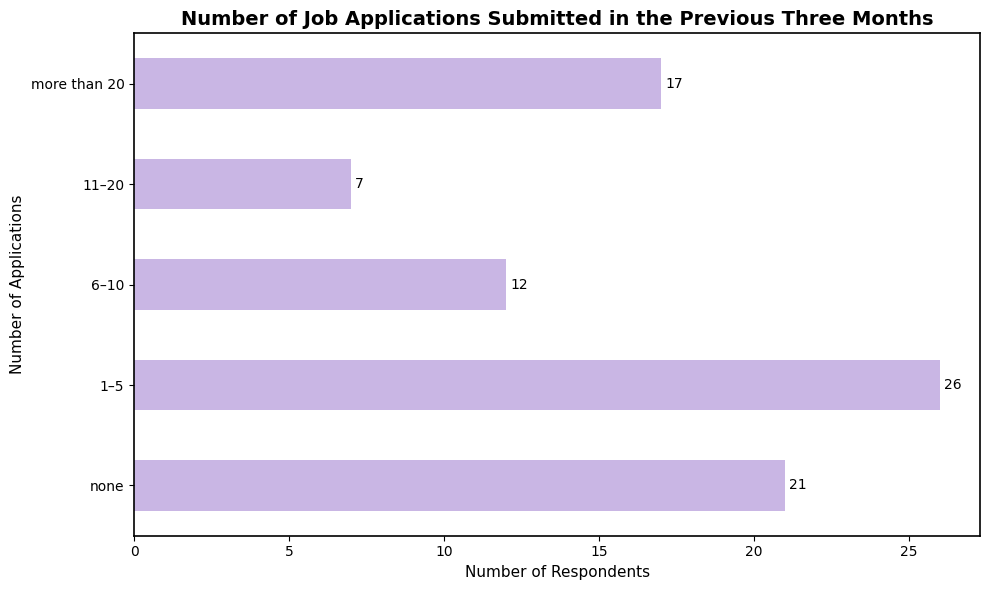

In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

# Define the correct order of application categories
application_order = [
    "none",
    "1–5",
    "6–10",
    "11–20",
    "more than 20"
]

# Count responses
application_counts = (
    df_youth["applications_3m"]
    .value_counts()
    .reindex(application_order)
    .dropna()
)

# Calculate percentages
application_summary = pd.DataFrame({
    "Count": application_counts.astype(int),
    "Percentage": (
        application_counts / application_counts.sum() * 100
    ).round(1)
})

print(application_summary)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

ax = application_counts.plot(
    kind="barh",
    color="#C9B6E4"
)

plt.title(
    "Number of Job Applications Submitted in the Previous Three Months",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Respondents", fontsize=11)
plt.ylabel("Number of Applications", fontsize=11)

# Add count labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=10
    )

# Increase plot border thickness
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

plt.tight_layout()

plt.savefig(
    "figures/youth_job_applications.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

                                            Count  Percentage
job_opportunity_source                                       
online job platforms / websites                54        65.1
social media                                   39        47.0
linkedin or professional platforms             36        43.4
friends or family                              35        42.2
personal or professional connections           14        16.9
i rarely hear about suitable opportunities     14        16.9
ngo or community organization                  14        16.9
university / educational institution            7         8.4
directly from employers                         7         8.4
recruitment agency                              5         6.0
other                                           1         1.2


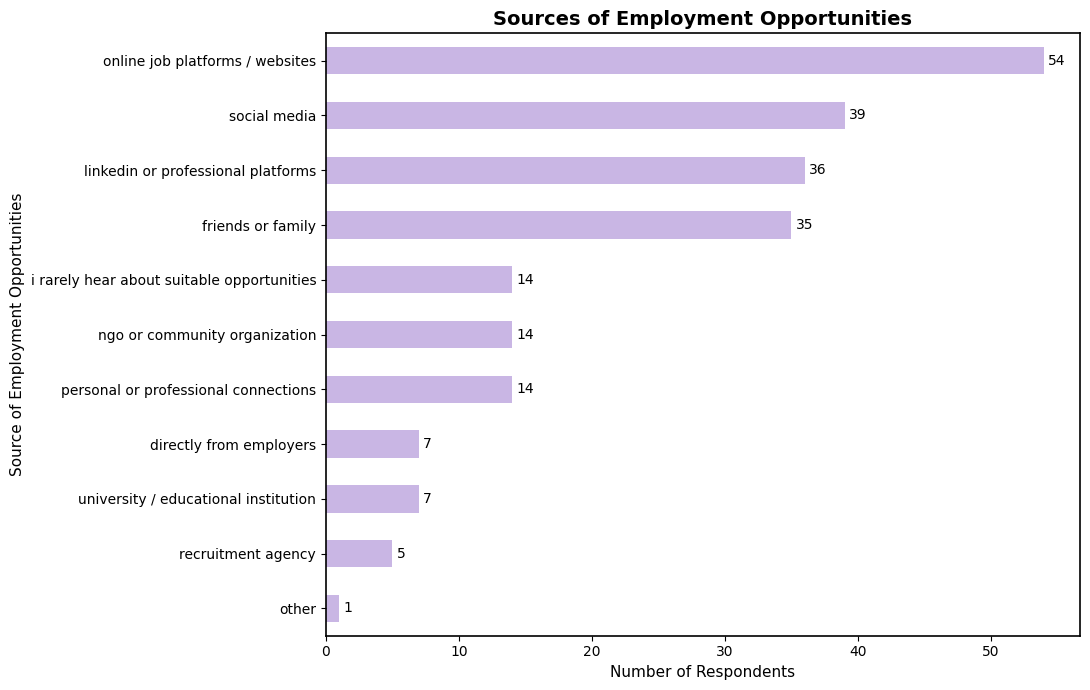

In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Create figures folder if it does not exist
os.makedirs("figures", exist_ok=True)

# ---------------------------------------------------------
# 1. Split and count multi-select responses
# ---------------------------------------------------------

source_counts = (
    df_youth["job_opportunity_source"]
    .dropna()
    .str.split("\n")
    .explode()
    .str.strip()
    .replace("", pd.NA)
    .dropna()
    .value_counts()
)

# ---------------------------------------------------------
# 2. Calculate percentages
# ---------------------------------------------------------

# Multiple-response question:
# percentages are calculated based on respondents who answered Q6
total_respondents = df_youth["job_opportunity_source"].notna().sum()

source_summary = pd.DataFrame({
    "Count": source_counts.astype(int),
    "Percentage": (
        source_counts / total_respondents * 100
    ).round(1)
})

print(source_summary)

# ---------------------------------------------------------
# 3. Sort for horizontal bar chart
# ---------------------------------------------------------

source_counts = source_counts.sort_values(ascending=True)

# ---------------------------------------------------------
# 4. Create horizontal bar chart
# ---------------------------------------------------------

plt.figure(figsize=(11, 7))

ax = source_counts.plot(
    kind="barh",
    color="#C9B6E4"
)

plt.title(
    "Sources of Employment Opportunities",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Number of Respondents",
    fontsize=11
)

plt.ylabel(
    "Source of Employment Opportunities",
    fontsize=11
)

# Add counts at the end of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=10
    )

# Slightly stronger borders
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

plt.tight_layout()

# ---------------------------------------------------------
# 5. Save figure
# ---------------------------------------------------------

plt.savefig(
    "figures/youth_opportunity_sources.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

                                                    Count  Percentage
job_search_barriers                                                  
lack of practical work experience                      36        43.4
location of available jobs / distance from wher...     35        42.2
high competition for available positions               32        38.6
limited job opportunities in my field                  28        33.7
transportation or commuting difficulties               21        25.3
salary levels offered by employers                     19        22.9
lack of professional connections or networking ...     18        21.7
discrimination or bias during the hiring process       17        20.5
stress, discouragement, or loss of motivation d...     10        12.0
lack of technical or digital skills required by...      9        10.8
lack of soft skills required by employers (e.g....      4         4.8
none of the above                                       1         1.2


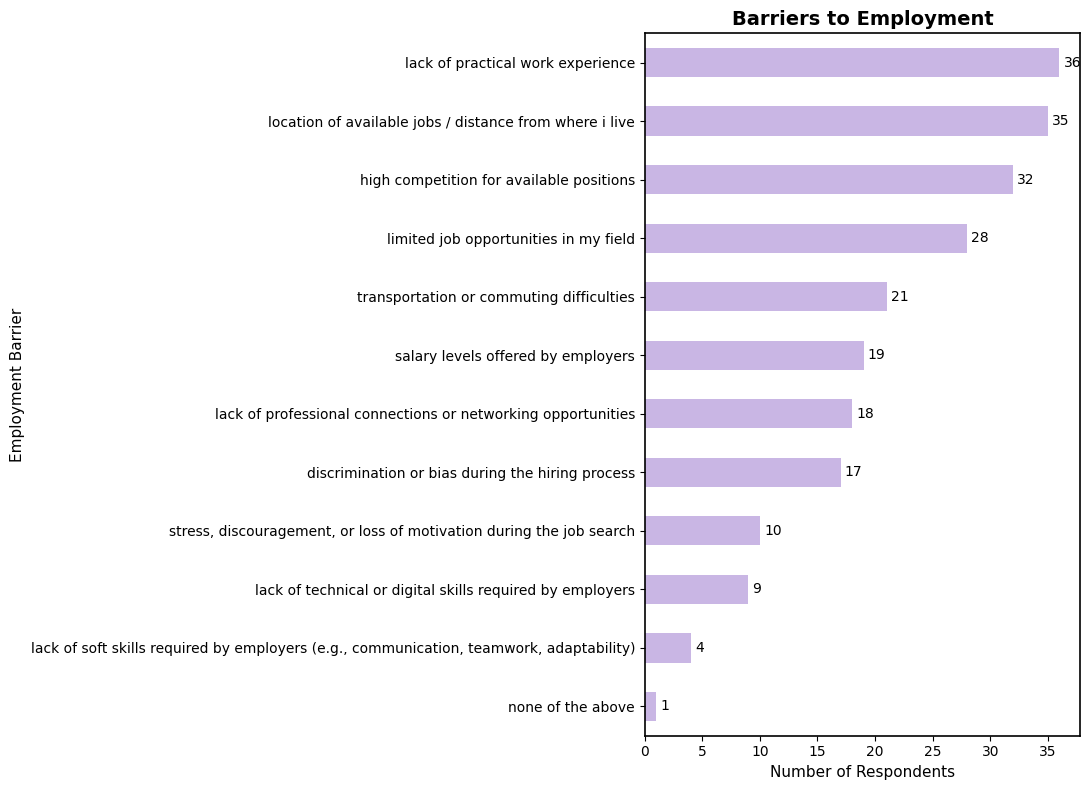

In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Create figures folder if it does not exist
os.makedirs("figures", exist_ok=True)

# ---------------------------------------------------------
# 1. Split and count multiple-response barriers
# ---------------------------------------------------------

barrier_counts = (
    df_youth["job_search_barriers"]
    .dropna()
    .str.split("\n")
    .explode()
    .str.strip()
    .replace("", pd.NA)
    .dropna()
    .value_counts()
)

# ---------------------------------------------------------
# 2. Calculate percentages
# ---------------------------------------------------------

# Percentage is based on respondents who answered the question
total_respondents = df_youth["job_search_barriers"].notna().sum()

barrier_summary = pd.DataFrame({
    "Count": barrier_counts.astype(int),
    "Percentage": (
        barrier_counts / total_respondents * 100
    ).round(1)
})

print(barrier_summary)

# ---------------------------------------------------------
# 3. Sort from lowest to highest for horizontal chart
# ---------------------------------------------------------

chart_counts = barrier_counts.sort_values(ascending=True)

# ---------------------------------------------------------
# 4. Create horizontal bar chart
# ---------------------------------------------------------

plt.figure(figsize=(11, 8))

ax = chart_counts.plot(
    kind="barh",
    color="#C9B6E4"
)

plt.title(
    "Barriers to Employment",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Number of Respondents",
    fontsize=11
)

plt.ylabel(
    "Employment Barrier",
    fontsize=11
)

# Add counts at the end of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=10
    )

# Improve chart borders
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

plt.tight_layout()

# ---------------------------------------------------------
# 5. Save figure
# ---------------------------------------------------------

plt.savefig(
    "figures/youth_barriers_ranked.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

                                               Count  Percentage
biggest_difficulty                                              
lack of practical work experience                 20        24.1
high competition for available positions          13        15.7
location / transportation                         13        15.7
limited job opportunities in my field             11        13.3
salary levels offered                             10        12.0
discrimination or bias                             6         7.2
lack of professional connections / networks        4         4.8
other                                              3         3.6
stress, discouragement, or loss of motivation      2         2.4
lack of technical or digital skills                1         1.2


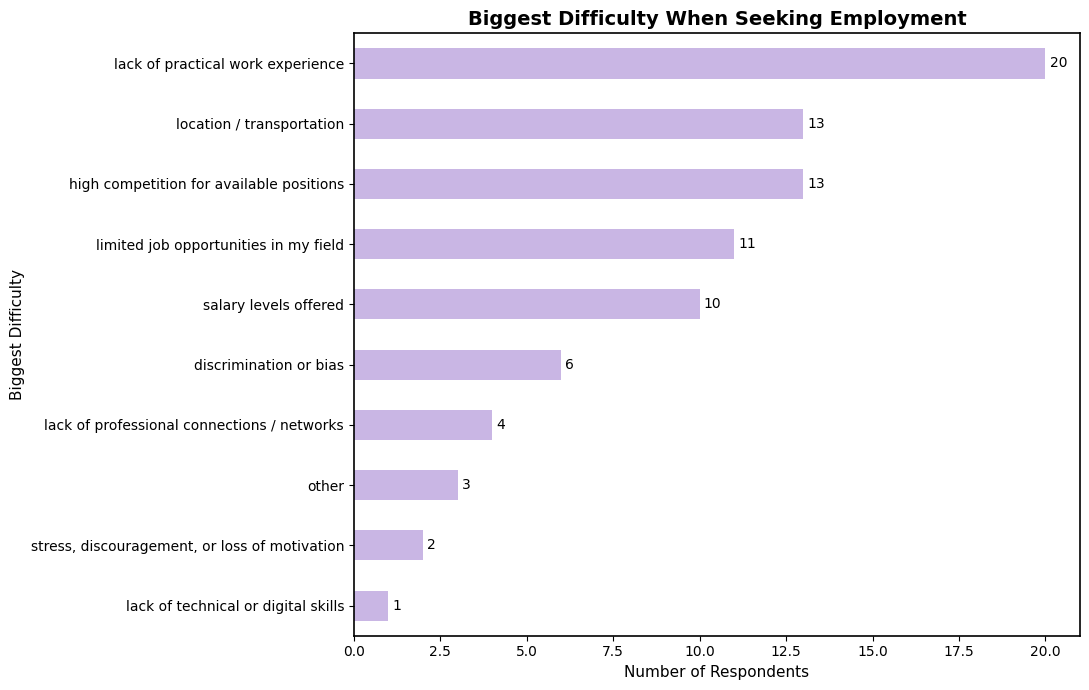

In [23]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Create figures folder if it does not exist
os.makedirs("figures", exist_ok=True)

# ---------------------------------------------------------
# 1. Count the single biggest difficulty
# ---------------------------------------------------------

biggest_difficulty_counts = (
    df_youth["biggest_difficulty"]
    .dropna()
    .value_counts()
)

# ---------------------------------------------------------
# 2. Calculate percentages
# ---------------------------------------------------------

total_respondents = df_youth["biggest_difficulty"].notna().sum()

biggest_difficulty_summary = pd.DataFrame({
    "Count": biggest_difficulty_counts.astype(int),
    "Percentage": (
        biggest_difficulty_counts / total_respondents * 100
    ).round(1)
})

print(biggest_difficulty_summary)

# ---------------------------------------------------------
# 3. Sort for horizontal ranked chart
# ---------------------------------------------------------

chart_counts = biggest_difficulty_counts.sort_values(ascending=True)

# ---------------------------------------------------------
# 4. Create horizontal bar chart
# ---------------------------------------------------------

plt.figure(figsize=(11, 7))

ax = chart_counts.plot(
    kind="barh",
    color="#C9B6E4"
)

plt.title(
    "Biggest Difficulty When Seeking Employment",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Number of Respondents",
    fontsize=11
)

plt.ylabel(
    "Biggest Difficulty",
    fontsize=11
)

# Add counts at the end of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=10
    )

# Stronger borders
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

plt.tight_layout()

# ---------------------------------------------------------
# 5. Save figure
# ---------------------------------------------------------

plt.savefig(
    "figures/youth_biggest_difficulty.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
import pandas as pd

# Keep respondents who answered both questions
df_cross = df_youth[
    df_youth["job_search_barriers"].notna() &
    df_youth["biggest_difficulty"].notna()
].copy()

# Split multiple barriers into separate rows
df_cross["job_search_barriers"] = (
    df_cross["job_search_barriers"]
    .str.split("\n")
)

df_cross = df_cross.explode("job_search_barriers")

# Clean whitespace
df_cross["job_search_barriers"] = (
    df_cross["job_search_barriers"]
    .str.strip()
)

# Remove empty values
df_cross = df_cross[
    df_cross["job_search_barriers"].notna() &
    (df_cross["job_search_barriers"] != "")
]

# ============================================================
# 1. CROSS-TABLE: COUNTS
# ============================================================

cross_table_count = pd.crosstab(
    df_cross["job_search_barriers"],
    df_cross["biggest_difficulty"]
)

print("CROSS-TABLE — COUNTS")
print(cross_table_count)


# ============================================================
# 2. CROSS-TABLE: ROW PERCENTAGES
# ============================================================

cross_table_pct = pd.crosstab(
    df_cross["job_search_barriers"],
    df_cross["biggest_difficulty"],
    normalize="index"
) * 100

cross_table_pct = cross_table_pct.round(1)

print("\nCROSS-TABLE — ROW PERCENTAGES (%)")
print(cross_table_pct)

CROSS-TABLE — COUNTS
biggest_difficulty                                  discrimination or bias  \
job_search_barriers                                                          
discrimination or bias during the hiring process                         5   
high competition for available positions                                 0   
lack of practical work experience                                        1   
lack of professional connections or networking ...                       0   
lack of soft skills required by employers (e.g....                       0   
lack of technical or digital skills required by...                       0   
limited job opportunities in my field                                    3   
location of available jobs / distance from wher...                       3   
none of the above                                                        0   
salary levels offered by employers                                       2   
stress, discouragement, or loss of motivati

MOST DIFFICULT STAGE — FREQUENCY TABLE
                                                    Count  Percentage
difficult_job_search_stage                                           
finding suitable job opportunities                     27        32.5
i have not yet reached any of these stages             19        22.9
receiving a job offer                                  10        12.0
getting invited to interviews                           9        10.8
deciding which opportunities to apply for               6         7.2
accepting an available offer because of salary ...      5         6.0
performing well in interviews or assessments            4         4.8
completing job applications                             2         2.4
staying in a job once hired                             1         1.2


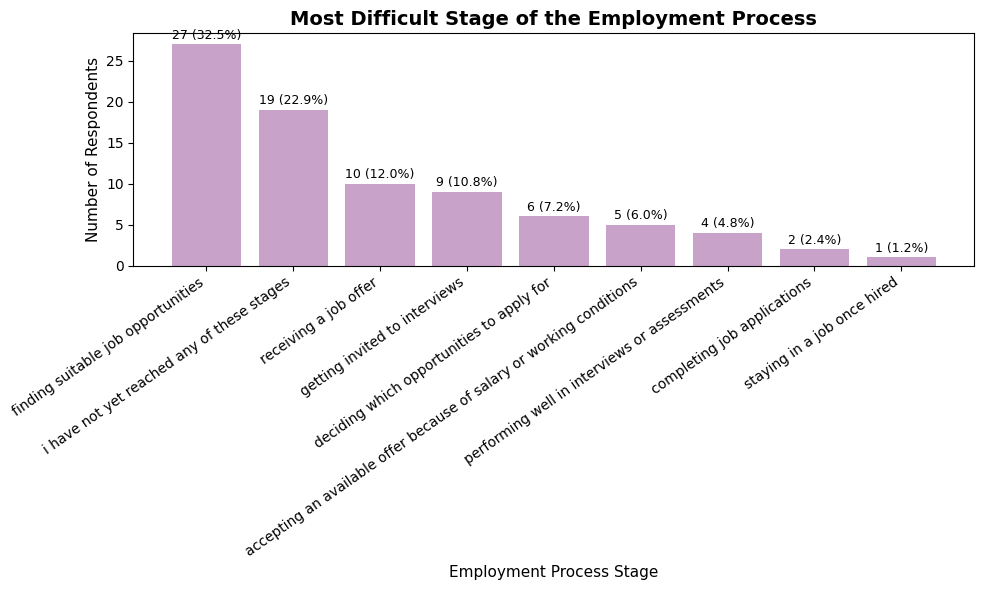

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# MOST DIFFICULT STAGE IN THE EMPLOYMENT PROCESS
# ============================================================

# Replace this with the exact name of your column
feature = 'difficult_job_search_stage'

# ------------------------------------------------------------
# 1. Frequency table
# ------------------------------------------------------------

stage_counts = df_youth[feature].value_counts(dropna=False)

# Percentage
stage_percentages = df_youth[feature].value_counts(normalize=True, dropna=False) * 100

# Combine counts and percentages
stage_table = pd.DataFrame({
    'Count': stage_counts,
    'Percentage': stage_percentages.round(1)
})

print("MOST DIFFICULT STAGE — FREQUENCY TABLE")
print(stage_table)


# ------------------------------------------------------------
# 2. Remove missing values for the visualization
# ------------------------------------------------------------

plot_data = df_youth[feature].dropna()

stage_counts = plot_data.value_counts()
stage_percentages = plot_data.value_counts(normalize=True) * 100

# ------------------------------------------------------------
# 3. Bar chart
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

bars = plt.bar(
    stage_counts.index,
    stage_counts.values,
    color='#C8A2C8'
)

plt.title(
    'Most Difficult Stage of the Employment Process',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Employment Process Stage', fontsize=11)
plt.ylabel('Number of Respondents', fontsize=11)

plt.xticks(
    rotation=35,
    ha='right'
)

# Add percentage labels above bars
for bar, percentage in zip(bars, stage_percentages.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{int(bar.get_height())} ({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    'figures/youth_employment_process.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

OUTCOMES AFTER JOB APPLICATIONS — FREQUENCY TABLE
                                                    Count  Percentage
application_outcome                                                  
i rarely receive any response                          36        43.4
i sometimes receive interviews but rarely progr...     12        14.5
i have received offers, but they were not suitable     11        13.3
i often reach later stages but do not receive o...      9        10.8
i receive rejections without an interview               8         9.6
i have received suitable offers but could not a...      7         8.4


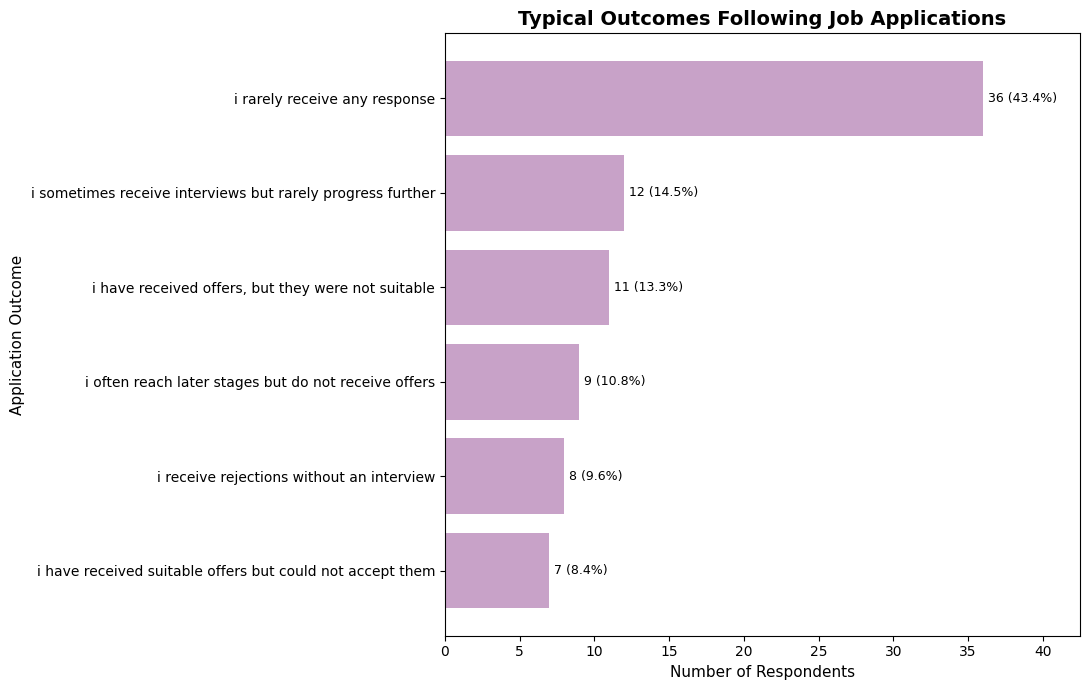

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# OUTCOMES AFTER JOB APPLICATIONS
# ============================================================

feature = 'application_outcome'

# ------------------------------------------------------------
# 1. Frequency table
# ------------------------------------------------------------

outcome_counts = df_youth[feature].value_counts(dropna=False)

outcome_percentages = (
    df_youth[feature]
    .value_counts(normalize=True, dropna=False) * 100
)

outcome_table = pd.DataFrame({
    'Count': outcome_counts,
    'Percentage': outcome_percentages.round(1)
})

print("OUTCOMES AFTER JOB APPLICATIONS — FREQUENCY TABLE")
print(outcome_table)


# ------------------------------------------------------------
# 2. Remove missing values for visualization
# ------------------------------------------------------------

plot_data = df_youth[feature].dropna()

outcome_counts = plot_data.value_counts()
outcome_percentages = plot_data.value_counts(normalize=True) * 100


# ------------------------------------------------------------
# 3. Horizontal bar chart
# ------------------------------------------------------------

plt.figure(figsize=(11, 7))

# Reverse order so the highest category appears at the top
counts = outcome_counts.sort_values()

bars = plt.barh(
    counts.index,
    counts.values,
    color='#C8A2C8'
)

plt.title(
    'Typical Outcomes Following Job Applications',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Number of Respondents',
    fontsize=11
)

plt.ylabel(
    'Application Outcome',
    fontsize=11
)

# ------------------------------------------------------------
# Add count and percentage labels
# ------------------------------------------------------------

percentages = (
    counts / len(plot_data) * 100
)

for bar, percentage in zip(bars, percentages):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

# Add some space on the right for labels
plt.xlim(0, counts.max() * 1.18)

plt.tight_layout()

# ------------------------------------------------------------
# 4. Save figure
# ------------------------------------------------------------

plt.savefig(
    'figures/youth_application_outcomes.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

EXPERIENCE REQUIREMENTS — FREQUENCY TABLE
                        Count  Percentage
experience_requirement                   
very often                 29        34.9
often                      16        19.3
sometimes                  25        30.1
rarely                      6         7.2
never                       6         7.2
not sure                    1         1.2


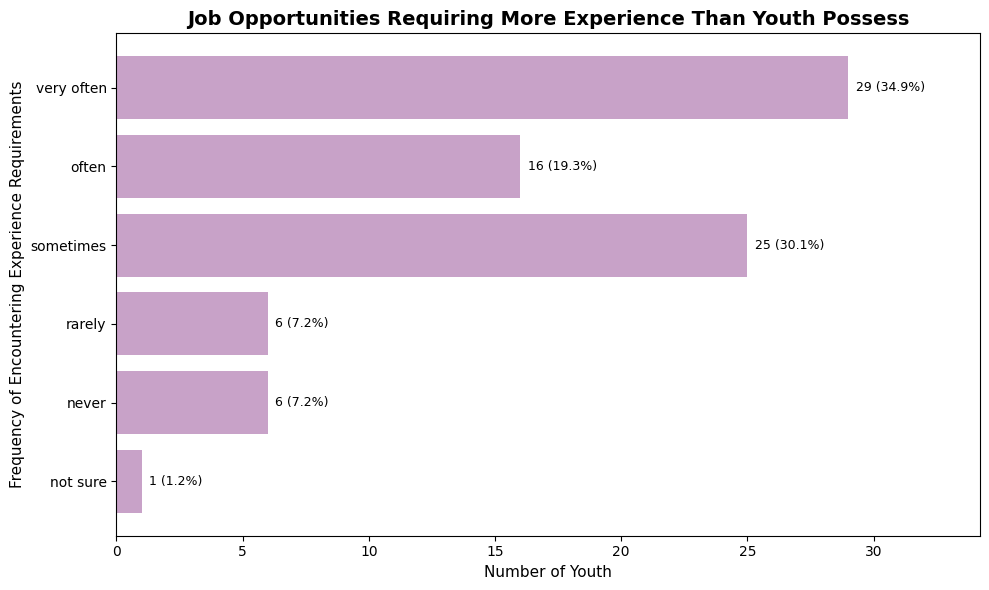

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

feature = 'experience_requirement'

# ---------------------------------------------------------
# Define the logical response order
# ---------------------------------------------------------
response_order = [
    'very often',
    'often',
    'sometimes',
    'rarely',
    'never',
    'not sure'
]

# Convert the feature to an ordered categorical variable
df_youth[feature] = pd.Categorical(
    df_youth[feature],
    categories=response_order,
    ordered=True
)

# ---------------------------------------------------------
# Frequency table
# ---------------------------------------------------------
experience_counts = (
    df_youth[feature]
    .value_counts(dropna=False)
    .reindex(response_order)
)

experience_percentages = (
    df_youth[feature]
    .value_counts(normalize=True, dropna=False)
    .reindex(response_order) * 100
)

experience_table = pd.DataFrame({
    'Count': experience_counts,
    'Percentage': experience_percentages.round(1)
})

print("EXPERIENCE REQUIREMENTS — FREQUENCY TABLE")
print(experience_table)

# ---------------------------------------------------------
# Plot excluding missing values
# ---------------------------------------------------------
plot_data = df_youth[feature].dropna()

experience_counts = (
    plot_data
    .value_counts()
    .reindex(response_order)
    .dropna()
)

# Reverse order because barh() displays the first category
# at the bottom
experience_counts = experience_counts.iloc[::-1]

# Calculate percentages based on non-missing responses
experience_percentages = (
    experience_counts / len(plot_data) * 100
)

# ---------------------------------------------------------
# Create figure
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

bars = plt.barh(
    experience_counts.index,
    experience_counts.values,
    color='#C8A2C8'
)

# ---------------------------------------------------------
# Title
# ---------------------------------------------------------
plt.title(
    'Job Opportunities Requiring More Experience Than Youth Possess',
    fontsize=14,
    fontweight='bold'
)

# ---------------------------------------------------------
# Axis labels
# ---------------------------------------------------------
plt.xlabel(
    'Number of Youth',
    fontsize=11
)

plt.ylabel(
    'Frequency of Encountering Experience Requirements',
    fontsize=11
)

# ---------------------------------------------------------
# Add count and percentage labels
# ---------------------------------------------------------
for bar, percentage in zip(bars, experience_percentages):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

# ---------------------------------------------------------
# Leave space for labels
# ---------------------------------------------------------
plt.xlim(
    0,
    experience_counts.max() * 1.18
)

plt.tight_layout()

# ---------------------------------------------------------
# Save figure
# ---------------------------------------------------------
plt.savefig(
    'figures/youth_experience_requirements.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

EDUCATION AND TRAINING PREPAREDNESS — FREQUENCY TABLE
                                                    Count  Percentage
education_job_preparation                                            
very well                                               0         0.0
well                                                    0         0.0
moderately                                             31        37.3
slightly                                               15        18.1
not at all                                              6         7.2
i have not received relevant education or training      5         6.0


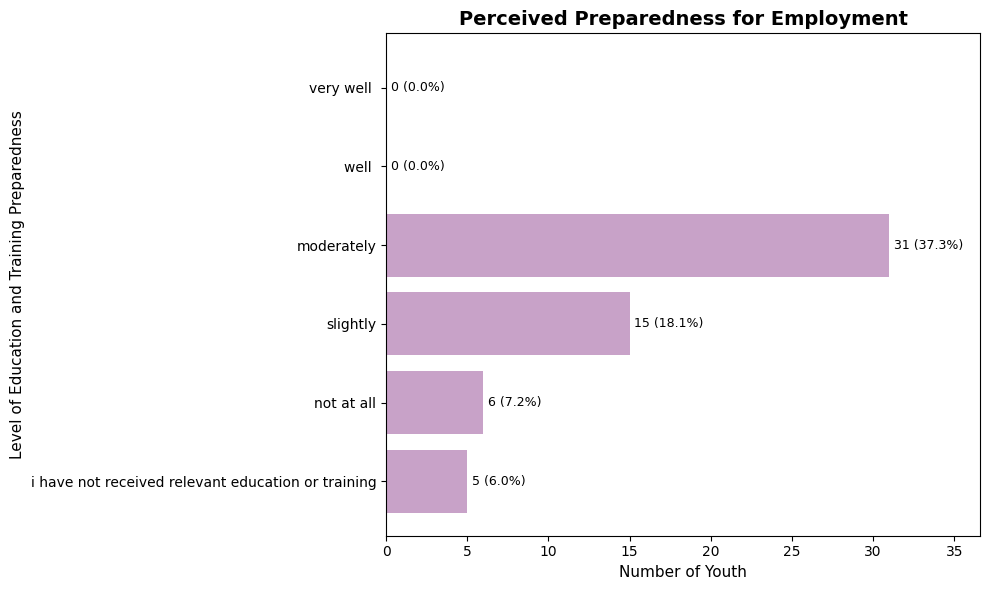


Number of youth reporting insufficient preparation: 52

MISSING SKILLS AMONG INSUFFICIENTLY PREPARED YOUTH
                                      Count  Percentage
Other                                     2         3.8
Problem-solving / critical thinking       5         9.6
Digital skills                            6        11.5
Professional certifications               8        15.4
Knowledge of the Lebanese job market      9        17.3
Communication skills                     11        21.2
English or other language skills         13        25.0
Interview skills                         18        34.6
Technical / job-specific skills          25        48.1
Practical work experience                27        51.9


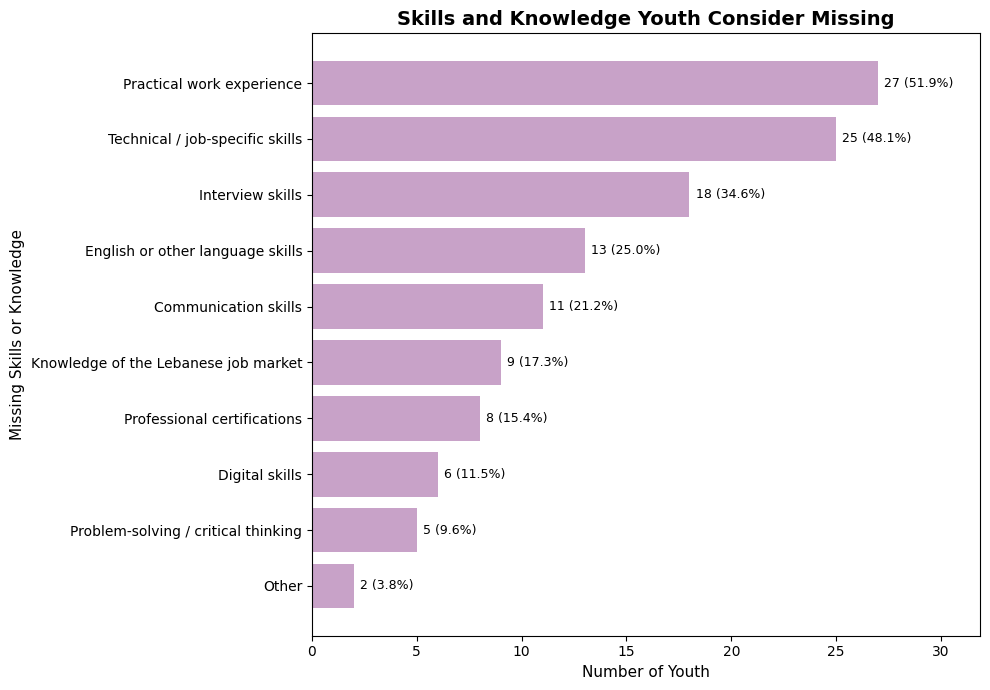

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. EDUCATION AND TRAINING PREPAREDNESS
# =========================================================

feature = 'education_job_preparation'

# Define the logical response order
response_order = [
    'very well ',
    'well ',
    'moderately',
    'slightly',
    'not at all',
    'i have not received relevant education or training'
]

# ---------------------------------------------------------
# Frequency table
# ---------------------------------------------------------

preparedness_counts = (
    df_youth[feature]
    .value_counts(dropna=False)
    .reindex(response_order)
    .fillna(0)
)

preparedness_percentages = (
    df_youth[feature]
    .value_counts(normalize=True, dropna=False)
    .reindex(response_order)
    .fillna(0) * 100
)

preparedness_table = pd.DataFrame({
    'Count': preparedness_counts.astype(int),
    'Percentage': preparedness_percentages.round(1)
})

print("EDUCATION AND TRAINING PREPAREDNESS — FREQUENCY TABLE")
print(preparedness_table)


# =========================================================
# 2. PREPAREDNESS CHART
# =========================================================

# Exclude missing values from the chart
plot_data = df_youth[feature].dropna()

preparedness_counts = (
    plot_data
    .value_counts()
    .reindex(response_order)
    .fillna(0)
)

# Reverse so barh() displays the desired order
# from top to bottom:
# Very well → Well → Moderately → Slightly → Not at all
# → No relevant education/training
preparedness_counts = preparedness_counts.iloc[::-1]

# Calculate percentages based on non-missing responses
preparedness_percentages = (
    preparedness_counts / len(plot_data) * 100
)

# ---------------------------------------------------------
# Create figure
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

bars = plt.barh(
    preparedness_counts.index,
    preparedness_counts.values,
    color='#C8A2C8'
)

# ---------------------------------------------------------
# Title
# ---------------------------------------------------------

plt.title(
    'Perceived Preparedness for Employment',
    fontsize=14,
    fontweight='bold'
)

# ---------------------------------------------------------
# Axis labels
# ---------------------------------------------------------

plt.xlabel(
    'Number of Youth',
    fontsize=11
)

plt.ylabel(
    'Level of Education and Training Preparedness',
    fontsize=11
)

# ---------------------------------------------------------
# Add count and percentage labels
# ---------------------------------------------------------

for bar, percentage in zip(bars, preparedness_percentages):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

# Leave space for labels
plt.xlim(
    0,
    max(preparedness_counts.max() * 1.18, 1)
)

plt.tight_layout()

# ---------------------------------------------------------
# Save figure
# ---------------------------------------------------------

plt.savefig(
    'figures/youth_preparedness.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# =========================================================
# 3. MISSING SKILLS AMONG INSUFFICIENTLY PREPARED YOUTH
# =========================================================

missing_skill_columns = [
    'missing_skills__communication_skills',
    'missing_skills__digital_skills',
    'missing_skills__english_or_other_language_skills',
    'missing_skills__interview_skills',
    'missing_skills__knowledge_of_the_lebanese_job_market',
    'missing_skills__other',
    'missing_skills__practical_work_experience',
    'missing_skills__problem_solving_critical_thinking',
    'missing_skills__professional_certifications',
    'missing_skills__technical_job_specific_skills'
]

# ---------------------------------------------------------
# Select youth who felt insufficiently prepared
# ---------------------------------------------------------

insufficient_preparation = df_youth[
    df_youth[feature].isin([
        'moderately',
        'slightly',
        'not at all'
    ])
].copy()

print(
    f"\nNumber of youth reporting insufficient preparation: "
    f"{len(insufficient_preparation)}"
)


# =========================================================
# 4. MISSING SKILLS FREQUENCY TABLE
# =========================================================

# Count selected skills
skill_counts = (
    insufficient_preparation[missing_skill_columns]
    .sum()
    .fillna(0)
)

# Convert technical column names into readable labels
skill_labels = {
    'missing_skills__communication_skills':
        'Communication skills',

    'missing_skills__digital_skills':
        'Digital skills',

    'missing_skills__english_or_other_language_skills':
        'English or other language skills',

    'missing_skills__interview_skills':
        'Interview skills',

    'missing_skills__knowledge_of_the_lebanese_job_market':
        'Knowledge of the Lebanese job market',

    'missing_skills__other':
        'Other',

    'missing_skills__practical_work_experience':
        'Practical work experience',

    'missing_skills__problem_solving_critical_thinking':
        'Problem-solving / critical thinking',

    'missing_skills__professional_certifications':
        'Professional certifications',

    'missing_skills__technical_job_specific_skills':
        'Technical / job-specific skills'
}

skill_counts.index = skill_counts.index.map(skill_labels)

# Sort from lowest to highest for barh()
skill_counts = skill_counts.sort_values()

# Calculate percentages
if len(insufficient_preparation) > 0:
    skill_percentages = (
        skill_counts / len(insufficient_preparation) * 100
    )
else:
    skill_percentages = skill_counts * 0

# Create table
missing_skills_table = pd.DataFrame({
    'Count': skill_counts.astype(int),
    'Percentage': skill_percentages.round(1)
})

print("\nMISSING SKILLS AMONG INSUFFICIENTLY PREPARED YOUTH")
print(missing_skills_table)


# =========================================================
# 5. MISSING SKILLS CHART
# =========================================================

plt.figure(figsize=(10, 7))

bars = plt.barh(
    skill_counts.index,
    skill_counts.values,
    color='#C8A2C8'
)

plt.title(
    'Skills and Knowledge Youth Consider Missing',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Number of Youth',
    fontsize=11
)

plt.ylabel(
    'Missing Skills or Knowledge',
    fontsize=11
)

# Add count and percentage labels
for bar, percentage in zip(bars, skill_percentages):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

# Leave space for labels
plt.xlim(
    0,
    max(skill_counts.max() * 1.18, 1)
)

plt.tight_layout()

# Save figure
plt.savefig(
    'figures/youth_missing_skills.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

MISSING SKILLS AND KNOWLEDGE — FREQUENCY TABLE
                                      Count  Percentage
Other                                     5         6.0
Problem-solving / critical thinking       6         7.2
Digital skills                            8         9.6
Professional certifications               9        10.8
Knowledge of the Lebanese job market     12        14.5
Communication skills                     16        19.3
English or other language skills         19        22.9
Interview skills                         21        25.3
Technical / job-specific skills          31        37.3
Practical work experience                32        38.6


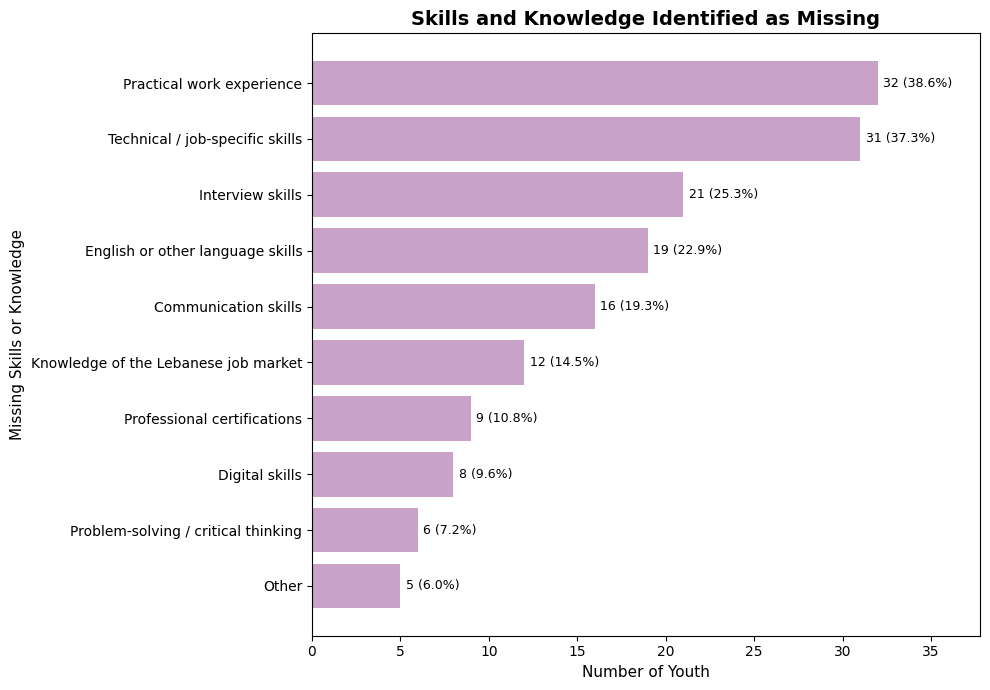

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# MISSING SKILLS AND KNOWLEDGE
# =========================================================

missing_skill_columns = [
    'missing_skills__communication_skills',
    'missing_skills__digital_skills',
    'missing_skills__english_or_other_language_skills',
    'missing_skills__interview_skills',
    'missing_skills__knowledge_of_the_lebanese_job_market',
    'missing_skills__other',
    'missing_skills__practical_work_experience',
    'missing_skills__problem_solving_critical_thinking',
    'missing_skills__professional_certifications',
    'missing_skills__technical_job_specific_skills'
]

# ---------------------------------------------------------
# 1. Calculate frequencies
# ---------------------------------------------------------

skill_counts = (
    df_youth[missing_skill_columns]
    .sum()
    .fillna(0)
)

# ---------------------------------------------------------
# 2. Convert column names to readable labels
# ---------------------------------------------------------

skill_labels = {
    'missing_skills__communication_skills':
        'Communication skills',

    'missing_skills__digital_skills':
        'Digital skills',

    'missing_skills__english_or_other_language_skills':
        'English or other language skills',

    'missing_skills__interview_skills':
        'Interview skills',

    'missing_skills__knowledge_of_the_lebanese_job_market':
        'Knowledge of the Lebanese job market',

    'missing_skills__other':
        'Other',

    'missing_skills__practical_work_experience':
        'Practical work experience',

    'missing_skills__problem_solving_critical_thinking':
        'Problem-solving / critical thinking',

    'missing_skills__professional_certifications':
        'Professional certifications',

    'missing_skills__technical_job_specific_skills':
        'Technical / job-specific skills'
}

skill_counts.index = skill_counts.index.map(skill_labels)

# ---------------------------------------------------------
# 3. Sort for horizontal bar chart
# ---------------------------------------------------------

skill_counts = skill_counts.sort_values()

# ---------------------------------------------------------
# 4. Calculate percentages
# ---------------------------------------------------------

total_youth = len(df_youth)

skill_percentages = (
    skill_counts / total_youth * 100
)

# ---------------------------------------------------------
# 5. Create frequency table
# ---------------------------------------------------------

missing_skills_table = pd.DataFrame({
    'Count': skill_counts.astype(int),
    'Percentage': skill_percentages.round(1)
})

print("MISSING SKILLS AND KNOWLEDGE — FREQUENCY TABLE")
print(missing_skills_table)


# =========================================================
# 6. CREATE CHART
# =========================================================

plt.figure(figsize=(10, 7))

bars = plt.barh(
    skill_counts.index,
    skill_counts.values,
    color='#C8A2C8'
)

plt.title(
    'Skills and Knowledge Identified as Missing',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Number of Youth',
    fontsize=11
)

plt.ylabel(
    'Missing Skills or Knowledge',
    fontsize=11
)

# ---------------------------------------------------------
# Add count and percentage labels
# ---------------------------------------------------------

for bar, percentage in zip(bars, skill_percentages):

    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

# Leave space for labels
plt.xlim(
    0,
    max(skill_counts.max() * 1.18, 1)
)

plt.tight_layout()

# ---------------------------------------------------------
# Save figure
# ---------------------------------------------------------

plt.savefig(
    'figures/youth_skill_gaps.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

IMPORTANCE OF PROFESSIONAL CONNECTIONS — FREQUENCY TABLE
                        Count  Percentage
importance_connections                   
extremely important        38        45.8
very important             27        32.5
moderately important        9        10.8
slightly important          2         2.4
not important at all        2         2.4
i don’t know                5         6.0


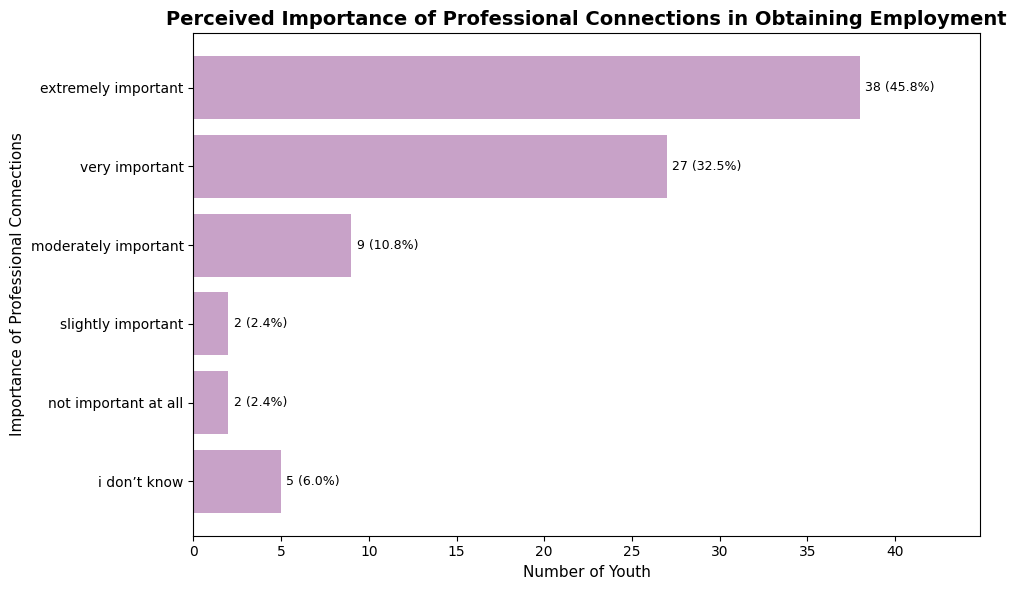

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# IMPORTANCE OF PROFESSIONAL CONNECTIONS
# =========================================================

feature = 'importance_connections'

# Display categories in logical order
response_order = [
    'extremely important',
    'very important',
    'moderately important',
    'slightly important',
    'not important at all',
    'i don’t know'
]

# ---------------------------------------------------------
# Frequency table
# ---------------------------------------------------------

importance_counts = (
    df_youth[feature]
    .value_counts(dropna=False)
    .reindex(response_order)
    .fillna(0)
)

importance_percentages = (
    df_youth[feature]
    .value_counts(normalize=True, dropna=False)
    .reindex(response_order)
    .fillna(0) * 100
)

importance_table = pd.DataFrame({
    'Count': importance_counts.astype(int),
    'Percentage': importance_percentages.round(1)
})

print("IMPORTANCE OF PROFESSIONAL CONNECTIONS — FREQUENCY TABLE")
print(importance_table)


# =========================================================
# CHART
# =========================================================

plot_data = df_youth[feature].dropna()

importance_counts = (
    plot_data
    .value_counts()
    .reindex(response_order)
    .fillna(0)
)

# Reverse for desired top-to-bottom order
importance_counts = importance_counts.iloc[::-1]

importance_percentages = (
    importance_counts / len(plot_data) * 100
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    importance_counts.index,
    importance_counts.values,
    color='#C8A2C8'
)

plt.title(
    'Perceived Importance of Professional Connections in Obtaining Employment',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Number of Youth',
    fontsize=11
)

plt.ylabel(
    'Importance of Professional Connections',
    fontsize=11
)

# Add count and percentage labels
for bar, percentage in zip(bars, importance_percentages):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

plt.xlim(
    0,
    max(importance_counts.max() * 1.18, 1)
)

plt.tight_layout()

plt.savefig(
    'figures/youth_network_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [41]:
# Check the actual values in the column
print(df_youth['importance_connections'].value_counts(dropna=False))

# Check how many observations there are
print("Total rows:", len(df_youth))

# Check missing values
print("Missing values:", df_youth['importance_connections'].isna().sum())

# Show every unique value, including its exact representation
print("\nUnique values:")
for value in df_youth['importance_connections'].unique():
    print(repr(value))

# Show rows that do not match the expected categories
expected_categories = [
    'extremely important',
    'very important',
    'moderately important',
    'slightly important',
    'not important at all',
    "i don't know"
]

unexpected = df_youth[
    ~df_youth['importance_connections'].isin(expected_categories)
]

print("\nUnexpected values:")
print(unexpected['importance_connections'].value_counts(dropna=False))

print("\nNumber of unexpected responses:", len(unexpected))

importance_connections
extremely important     38
very important          27
moderately important     9
i don’t know             5
not important at all     2
slightly important       2
Name: count, dtype: int64
Total rows: 83
Missing values: 0

Unique values:
'extremely important'
'very important'
'moderately important'
'i don’t know'
'not important at all'
'slightly important'

Unexpected values:
importance_connections
i don’t know    5
Name: count, dtype: int64

Number of unexpected responses: 5


NEED FOR REFERRALS — FREQUENCY TABLE
                   Count  Percentage
needed_connection                   
yes, frequently       41        49.4
yes, sometimes        31        37.3
rarely                 4         4.8
never                  4         4.8
not sure               3         3.6

Total: 83
Percentage: 99.89999999999998


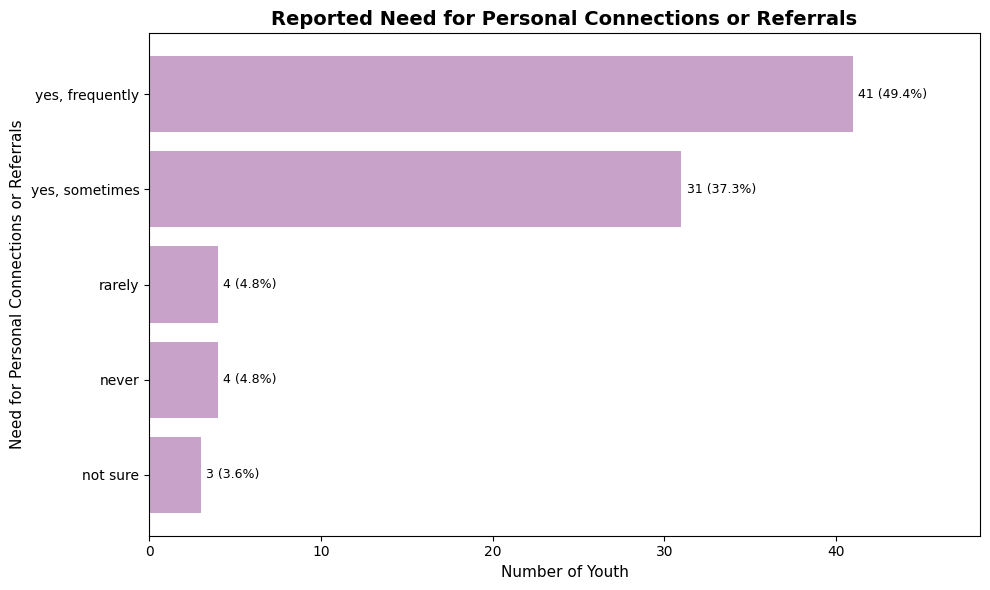

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# NEED FOR REFERRALS
# =========================================================

feature = 'needed_connection'

# ---------------------------------------------------------
# Frequency table using actual dataset values
# ---------------------------------------------------------

referral_counts = (
    df_youth[feature]
    .value_counts(dropna=False)
)

referral_percentages = (
    df_youth[feature]
    .value_counts(dropna=False, normalize=True) * 100
)

referral_table = pd.DataFrame({
    'Count': referral_counts,
    'Percentage': referral_percentages.round(1)
})

print("NEED FOR REFERRALS — FREQUENCY TABLE")
print(referral_table)

print("\nTotal:", referral_table['Count'].sum())
print("Percentage:", referral_table['Percentage'].sum())


# =========================================================
# CHART
# =========================================================

# Exclude missing values from the chart
plot_data = df_youth[feature].dropna()

referral_counts = plot_data.value_counts()

referral_percentages = (
    referral_counts / len(plot_data) * 100
)

# Reverse order for horizontal bar chart
referral_counts = referral_counts.iloc[::-1]
referral_percentages = referral_percentages.iloc[::-1]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    referral_counts.index.astype(str),
    referral_counts.values,
    color='#C8A2C8'
)

plt.title(
    'Reported Need for Personal Connections or Referrals',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Number of Youth',
    fontsize=11
)

plt.ylabel(
    'Need for Personal Connections or Referrals',
    fontsize=11
)

# Add count and percentage labels
for bar, percentage in zip(bars, referral_percentages):

    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

plt.xlim(
    0,
    max(referral_counts.max() * 1.18, 1)
)

plt.tight_layout()

plt.savefig(
    'figures/youth_referrals.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

INTERVIEW EXPERIENCE — FREQUENCY TABLE
                                  Count  Percentage
interview_without_offer                            
never                                26        31.3
2–3 times                            18        21.7
once                                 17        20.5
i have never had a job interview     10        12.0
more than 5 times                     6         7.2
4–5 times                             6         7.2

Total: 83
Percentage: 99.9


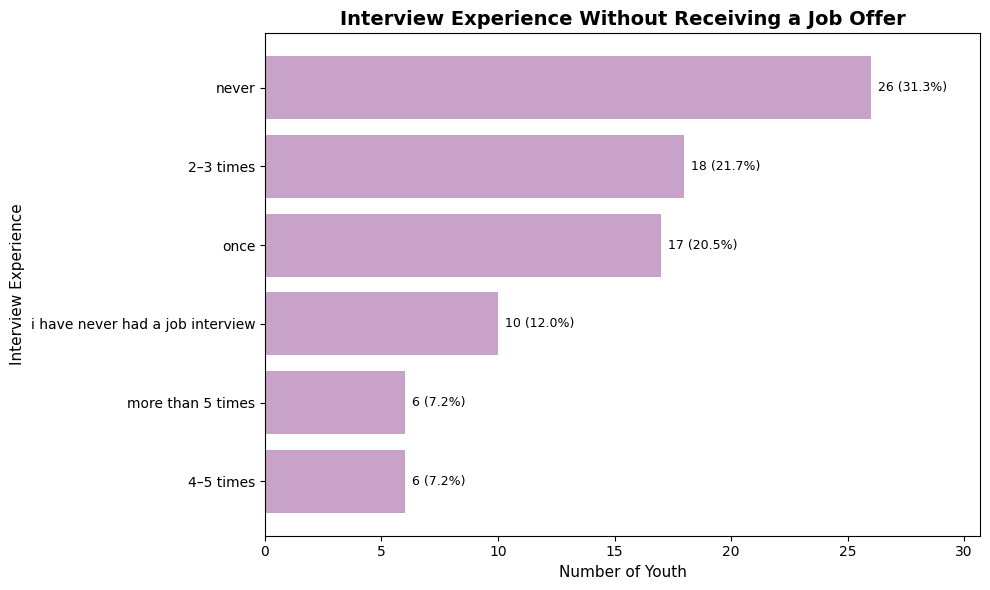


INTERVIEW DIFFICULTIES — FREQUENCY TABLE
                                            Count  Percentage
Online interview technology                     3         3.6
Answering behavioral or personal questions      6         7.2
Interviews in english or another language      14        16.9
Explaining my skills and experience            14        16.9
Managing stress or nervousness                 16        19.3
Communicating confidently                      17        20.5
Understanding what employers expect            17        20.5
Answering technical job specific questions     19        22.9


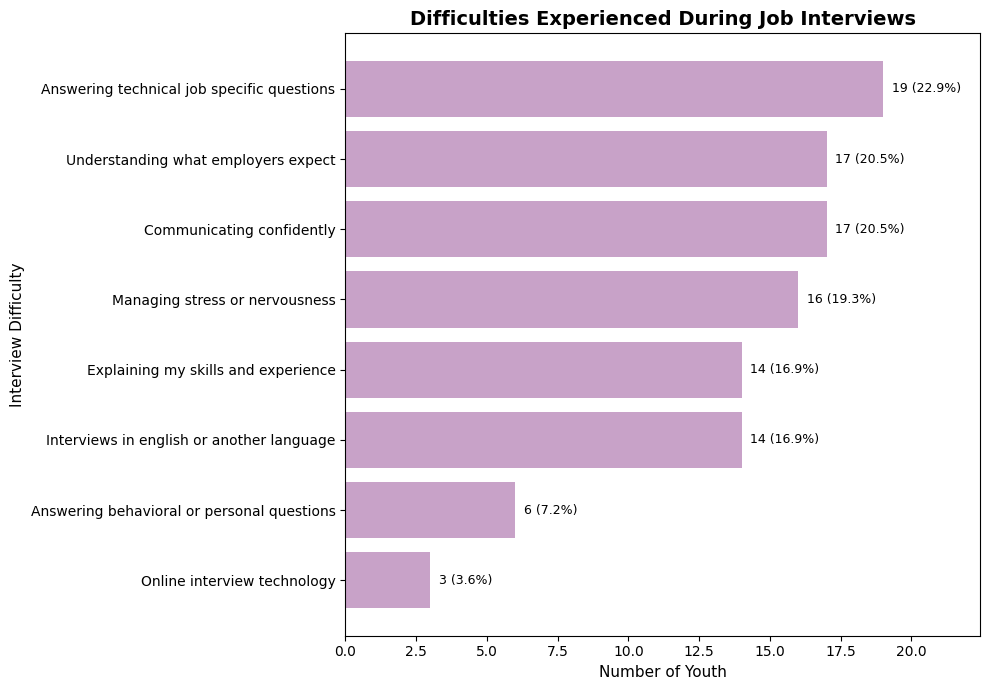

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# INTERVIEW EXPERIENCE
# =========================================================

feature = 'interview_without_offer'

# ---------------------------------------------------------
# Frequency table using actual dataset values
# ---------------------------------------------------------

interview_counts = (
    df_youth[feature]
    .value_counts(dropna=False)
)

interview_percentages = (
    df_youth[feature]
    .value_counts(dropna=False, normalize=True) * 100
)

interview_table = pd.DataFrame({
    'Count': interview_counts,
    'Percentage': interview_percentages.round(1)
})

print("INTERVIEW EXPERIENCE — FREQUENCY TABLE")
print(interview_table)

print("\nTotal:", interview_table['Count'].sum())
print("Percentage:", interview_table['Percentage'].sum())


# =========================================================
# CHART — INTERVIEW EXPERIENCE
# =========================================================

plot_data = df_youth[feature].dropna()

interview_counts = plot_data.value_counts()

interview_percentages = (
    interview_counts / len(plot_data) * 100
)

# Reverse order for horizontal bar chart
interview_counts = interview_counts.iloc[::-1]
interview_percentages = interview_percentages.iloc[::-1]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    interview_counts.index.astype(str),
    interview_counts.values,
    color='#C8A2C8'
)

plt.title(
    'Interview Experience Without Receiving a Job Offer',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Number of Youth',
    fontsize=11
)

plt.ylabel(
    'Interview Experience',
    fontsize=11
)

# Add count and percentage labels
for bar, percentage in zip(bars, interview_percentages):

    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

plt.xlim(
    0,
    max(interview_counts.max() * 1.18, 1)
)

plt.tight_layout()

plt.savefig(
    'figures/youth_interview_experience.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# =========================================================
# INTERVIEW DIFFICULTIES
# =========================================================
# This section assumes the interview_difficulties__*
# columns are binary/multiple-response indicators.

difficulty_columns = [
    col for col in df_youth.columns
    if col.startswith('interview_difficulties__')
]

difficulty_counts = (
    df_youth[difficulty_columns]
    .sum()
    .fillna(0)
)

# Convert technical column names into readable labels
difficulty_labels = {
    col: col.replace(
        'interview_difficulties__',
        ''
    ).replace('_', ' ').capitalize()
    for col in difficulty_columns
}

difficulty_counts.index = difficulty_counts.index.map(
    difficulty_labels
)

# Sort for horizontal chart
difficulty_counts = difficulty_counts.sort_values()

# Percentage based on the full youth sample
difficulty_percentages = (
    difficulty_counts / len(df_youth) * 100
)

difficulty_table = pd.DataFrame({
    'Count': difficulty_counts.astype(int),
    'Percentage': difficulty_percentages.round(1)
})

print("\nINTERVIEW DIFFICULTIES — FREQUENCY TABLE")
print(difficulty_table)


# =========================================================
# CHART — INTERVIEW DIFFICULTIES
# =========================================================

plt.figure(figsize=(10, 7))

bars = plt.barh(
    difficulty_counts.index,
    difficulty_counts.values,
    color='#C8A2C8'
)

plt.title(
    'Difficulties Experienced During Job Interviews',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Number of Youth',
    fontsize=11
)

plt.ylabel(
    'Interview Difficulty',
    fontsize=11
)

for bar, percentage in zip(
    bars,
    difficulty_percentages
):

    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

plt.xlim(
    0,
    max(difficulty_counts.max() * 1.18, 1)
)

plt.tight_layout()

plt.savefig(
    'figures/youth_interview_difficulties.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

EFFECTS OF REPEATED REJECTION — FREQUENCY TABLE
                                               Count  Percentage
rejection_effect                                                
i continue applying, but with less motivation     33        39.8
no effect — i continue applying as usual          31        37.3
i stop applying for jobs for a period of time      8         9.6
i reduce the number of jobs i apply for            7         8.4
i stop applying for jobs altogether                4         4.8

Total: 83
Percentage: 99.89999999999999


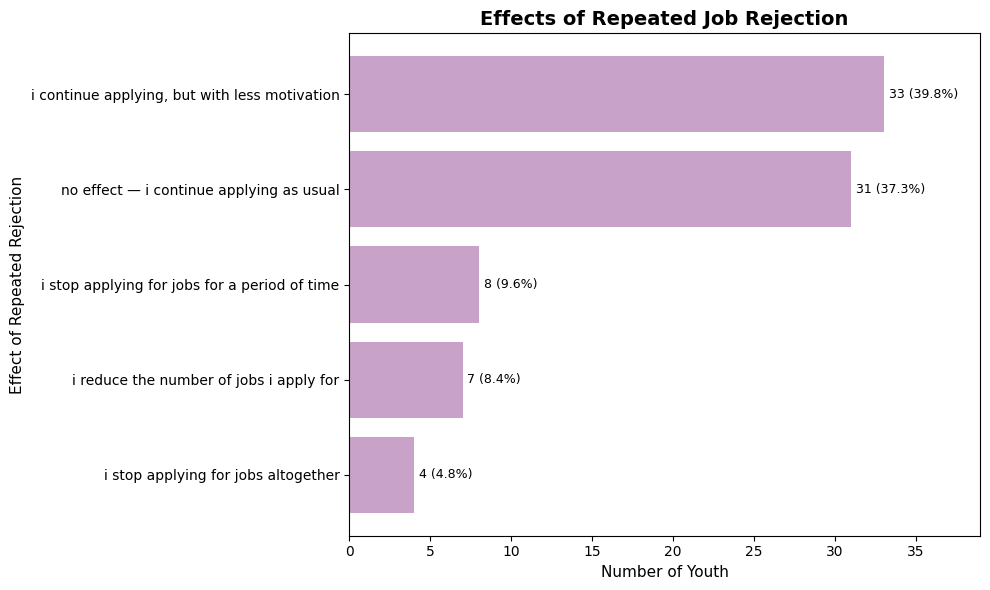

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# EFFECTS OF REPEATED REJECTION
# =========================================================

feature = 'rejection_effect'

# ---------------------------------------------------------
# Frequency table using actual dataset values
# ---------------------------------------------------------

rejection_counts = (
    df_youth[feature]
    .value_counts(dropna=False)
)

rejection_percentages = (
    df_youth[feature]
    .value_counts(dropna=False, normalize=True) * 100
)

rejection_table = pd.DataFrame({
    'Count': rejection_counts,
    'Percentage': rejection_percentages.round(1)
})

print("EFFECTS OF REPEATED REJECTION — FREQUENCY TABLE")
print(rejection_table)

print("\nTotal:", rejection_table['Count'].sum())
print("Percentage:", rejection_table['Percentage'].sum())


# =========================================================
# CHART
# =========================================================

# Exclude missing values from the chart
plot_data = df_youth[feature].dropna()

rejection_counts = plot_data.value_counts()

rejection_percentages = (
    rejection_counts / len(plot_data) * 100
)

# Reverse order for horizontal bar chart
rejection_counts = rejection_counts.iloc[::-1]
rejection_percentages = rejection_percentages.iloc[::-1]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    rejection_counts.index.astype(str),
    rejection_counts.values,
    color='#C8A2C8'
)

plt.title(
    'Effects of Repeated Job Rejection',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Number of Youth',
    fontsize=11
)

plt.ylabel(
    'Effect of Repeated Rejection',
    fontsize=11
)

# Add count and percentage labels
for bar, percentage in zip(
    bars,
    rejection_percentages
):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

plt.xlim(
    0,
    max(rejection_counts.max() * 1.18, 1)
)

plt.tight_layout()

plt.savefig(
    'figures/youth_rejection_effects.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

EMPLOYER FEEDBACK — FREQUENCY TABLE
                                     Count  Percentage
employer_feedback                                     
i usually do not receive a response     25        30.1
almost never                            23        27.7
rarely                                  18        21.7
sometimes                               12        14.5
often                                    5         6.0

Total: 83
Percentage: 100.0


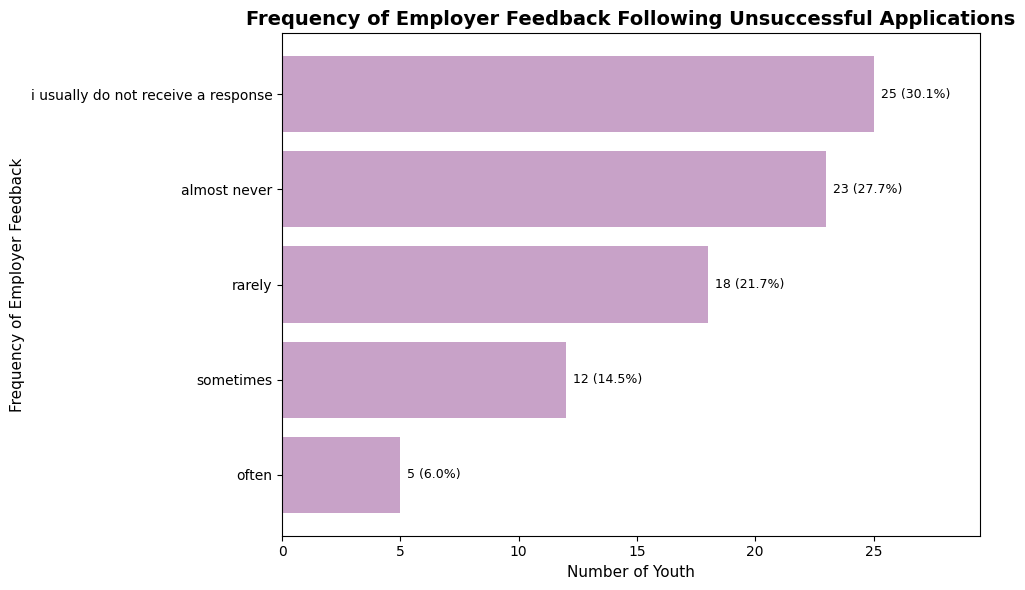

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# EMPLOYER FEEDBACK
# =========================================================

feature = 'employer_feedback'

# Frequency table using actual dataset values
feedback_counts = (
    df_youth[feature]
    .value_counts(dropna=False)
)

feedback_percentages = (
    df_youth[feature]
    .value_counts(dropna=False, normalize=True) * 100
)

feedback_table = pd.DataFrame({
    'Count': feedback_counts,
    'Percentage': feedback_percentages.round(1)
})

print("EMPLOYER FEEDBACK — FREQUENCY TABLE")
print(feedback_table)

print("\nTotal:", feedback_table['Count'].sum())
print("Percentage:", feedback_table['Percentage'].sum())


# =========================================================
# CHART
# =========================================================

plot_data = df_youth[feature].dropna()

feedback_counts = plot_data.value_counts()
feedback_percentages = feedback_counts / len(plot_data) * 100

# Reverse for horizontal chart
feedback_counts = feedback_counts.iloc[::-1]
feedback_percentages = feedback_percentages.iloc[::-1]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    feedback_counts.index.astype(str),
    feedback_counts.values,
    color='#C8A2C8'
)

plt.title(
    'Frequency of Employer Feedback Following Unsuccessful Applications',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Number of Youth',
    fontsize=11
)

plt.ylabel(
    'Frequency of Employer Feedback',
    fontsize=11
)

# Add count and percentage labels
for bar, percentage in zip(bars, feedback_percentages):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

plt.xlim(
    0,
    max(feedback_counts.max() * 1.18, 1)
)

plt.tight_layout()

plt.savefig(
    'figures/youth_employer_feedback.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

SECURITY SITUATION — FREQUENCY TABLE
                    Count  Percentage
security_impact                      
significantly          26        31.3
very significantly     22        26.5
moderately             18        21.7
slightly                9        10.8
not at all              8         9.6

Total: 83
Percentage: 99.89999999999999


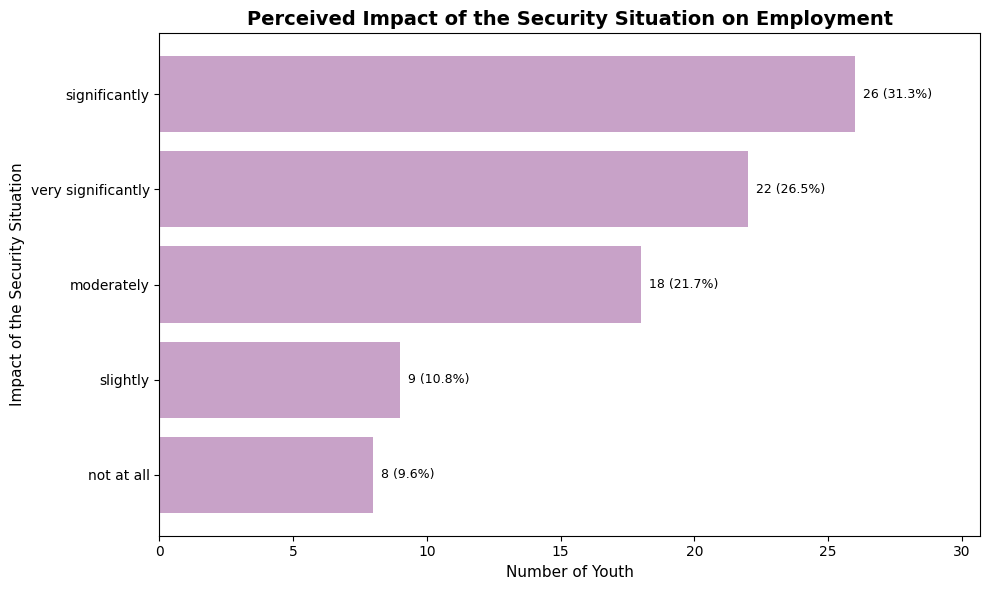

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# IMPACT OF THE SECURITY SITUATION
# =========================================================

feature = 'security_impact'

# Frequency table using actual dataset values
security_counts = (
    df_youth[feature]
    .value_counts(dropna=False)
)

security_percentages = (
    df_youth[feature]
    .value_counts(dropna=False, normalize=True) * 100
)

security_table = pd.DataFrame({
    'Count': security_counts,
    'Percentage': security_percentages.round(1)
})

print("SECURITY SITUATION — FREQUENCY TABLE")
print(security_table)

print("\nTotal:", security_table['Count'].sum())
print("Percentage:", security_table['Percentage'].sum())


# =========================================================
# CHART
# =========================================================

plot_data = df_youth[feature].dropna()

security_counts = plot_data.value_counts()
security_percentages = security_counts / len(plot_data) * 100

# Reverse for horizontal chart
security_counts = security_counts.iloc[::-1]
security_percentages = security_percentages.iloc[::-1]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    security_counts.index.astype(str),
    security_counts.values,
    color='#C8A2C8'
)

plt.title(
    'Perceived Impact of the Security Situation on Employment',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Number of Youth',
    fontsize=11
)

plt.ylabel(
    'Impact of the Security Situation',
    fontsize=11
)

# Add count and percentage labels
for bar, percentage in zip(bars, security_percentages):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

plt.xlim(
    0,
    max(security_counts.max() * 1.18, 1)
)

plt.tight_layout()

plt.savefig(
    'figures/youth_security_impact.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

FACTORS AFFECTING JOB ACCEPTANCE — FREQUENCY TABLE
                                                    Count  Percentage
Other                                                   4         4.8
Lack of job security                                   11        13.3
Lack of career progression                             14        16.9
Job responsibilities do not match my qualificat...     15        18.1
Long commuting distance                                15        18.1
Lack of benefits                                       16        19.3
Lack of remote hybrid options                          17        20.5
Poor working conditions                                18        21.7
Long working hours                                     24        28.9
Lack of training or learning opportunities             25        30.1
Salary does not cover basic living costs               42        50.6
Low salary                                             44        53.0

Total respondents: 83


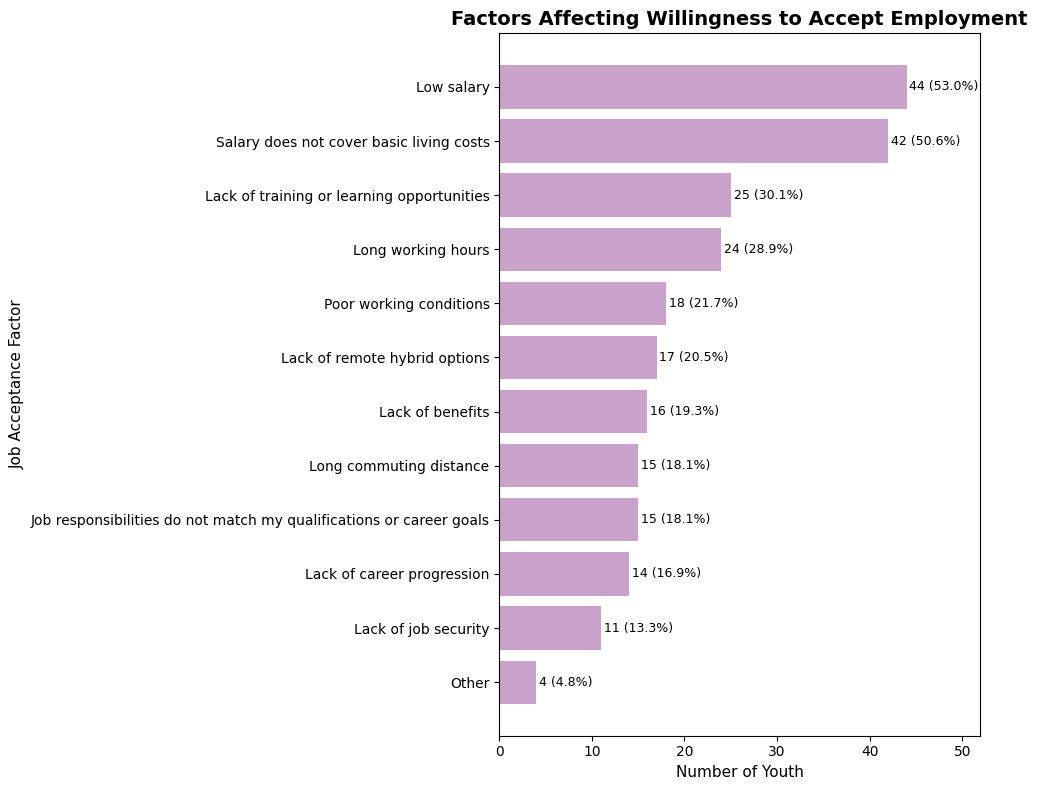

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# FACTORS AFFECTING JOB ACCEPTANCE
# =========================================================

# Multiple-response columns
acceptance_columns = [
    col for col in df_youth.columns
    if col.startswith('job_acceptance_barriers__')
]

# Count how many respondents selected each factor
acceptance_counts = (
    df_youth[acceptance_columns]
    .sum()
    .fillna(0)
    .sort_values()
)

# Convert column names into readable labels
acceptance_labels = {
    col: col.replace(
        'job_acceptance_barriers__',
        ''
    ).replace('_', ' ').capitalize()
    for col in acceptance_columns
}

acceptance_counts.index = acceptance_counts.index.map(acceptance_labels)

# Percentage of all respondents
acceptance_percentages = (
    acceptance_counts / len(df_youth) * 100
)

# Frequency table
acceptance_table = pd.DataFrame({
    'Count': acceptance_counts.astype(int),
    'Percentage': acceptance_percentages.round(1)
})

print("FACTORS AFFECTING JOB ACCEPTANCE — FREQUENCY TABLE")
print(acceptance_table)

print("\nTotal respondents:", len(df_youth))


# =========================================================
# CHART
# =========================================================

plt.figure(figsize=(10, 8))

bars = plt.barh(
    acceptance_counts.index,
    acceptance_counts.values,
    color='#C8A2C8'
)

plt.title(
    'Factors Affecting Willingness to Accept Employment',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Number of Youth',
    fontsize=11
)

plt.ylabel(
    'Job Acceptance Factor',
    fontsize=11
)

# Add count and percentage labels
for bar, percentage in zip(
    bars,
    acceptance_percentages
):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

plt.xlim(
    0,
    max(acceptance_counts.max() * 1.18, 1)
)

plt.tight_layout()

plt.savefig(
    'figures/youth_job_acceptance_factors.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

RESPONSES TO INSUFFICIENT SALARY — FREQUENCY TABLE
                                                  Count  Percentage
low_salary_response                                                
accept the job temporarily                           28        33.7
continue searching for a better-paying job           20        24.1
work two or more jobs                                14        16.9
negotiate for a higher salary or better benefits      7         8.4
consider working abroad or emigrating                 5         6.0
rely on family support while searching                4         4.8
turn to freelancing or online work                    3         3.6
leave the labour market temporarily                   2         2.4

Total: 83
Percentage: 99.89999999999999


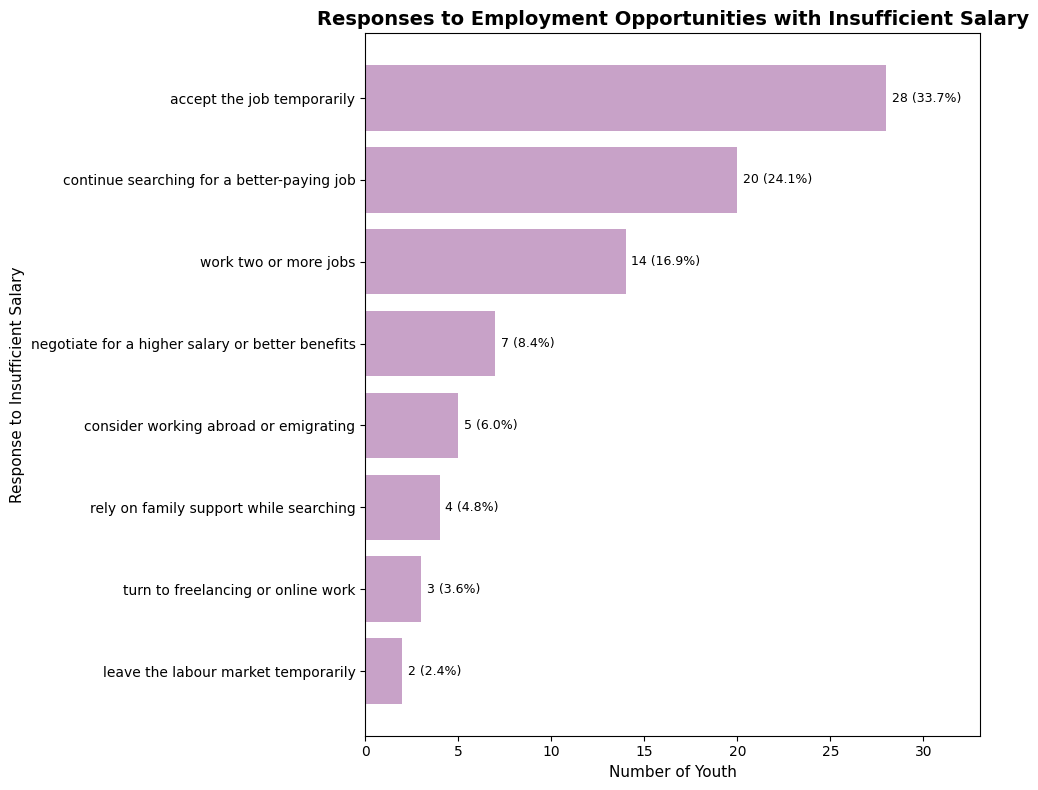

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# RESPONSES TO INSUFFICIENT SALARY
# =========================================================

feature = 'low_salary_response'

# Frequency table using actual dataset values
salary_counts = (
    df_youth[feature]
    .value_counts(dropna=False)
)

salary_percentages = (
    df_youth[feature]
    .value_counts(dropna=False, normalize=True) * 100
)

salary_table = pd.DataFrame({
    'Count': salary_counts,
    'Percentage': salary_percentages.round(1)
})

print("RESPONSES TO INSUFFICIENT SALARY — FREQUENCY TABLE")
print(salary_table)

print("\nTotal:", salary_table['Count'].sum())
print("Percentage:", salary_table['Percentage'].sum())


# =========================================================
# CHART
# =========================================================

plot_data = df_youth[feature].dropna()

salary_counts = plot_data.value_counts()
salary_percentages = salary_counts / len(plot_data) * 100

# Reverse for horizontal chart
salary_counts = salary_counts.iloc[::-1]
salary_percentages = salary_percentages.iloc[::-1]

plt.figure(figsize=(10, 8))

bars = plt.barh(
    salary_counts.index.astype(str),
    salary_counts.values,
    color='#C8A2C8'
)

plt.title(
    'Responses to Employment Opportunities with Insufficient Salary',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Number of Youth',
    fontsize=11
)

plt.ylabel(
    'Response to Insufficient Salary',
    fontsize=11
)

# Add count and percentage labels
for bar, percentage in zip(bars, salary_percentages):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

plt.xlim(
    0,
    max(salary_counts.max() * 1.18, 1)
)

plt.tight_layout()

plt.savefig(
    'figures/youth_salary_response.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

ACCESS TO MODERN WORK OPPORTUNITIES — FREQUENCY TABLE
                                                    Count  Percentage
modern_work_access                                                   
i know about them but do not know how to access...     21        25.3
i do not know enough about these opportunities         17        20.5
i have access and have already used these oppor...     15        18.1
i have the skills but face technical, payment, ...     10        12.0
i have no access to such opportunities                  8         9.6
i lack the skills needed                                7         8.4
these opportunities are not relevant to my field        5         6.0

Total: 83
Percentage: 99.9


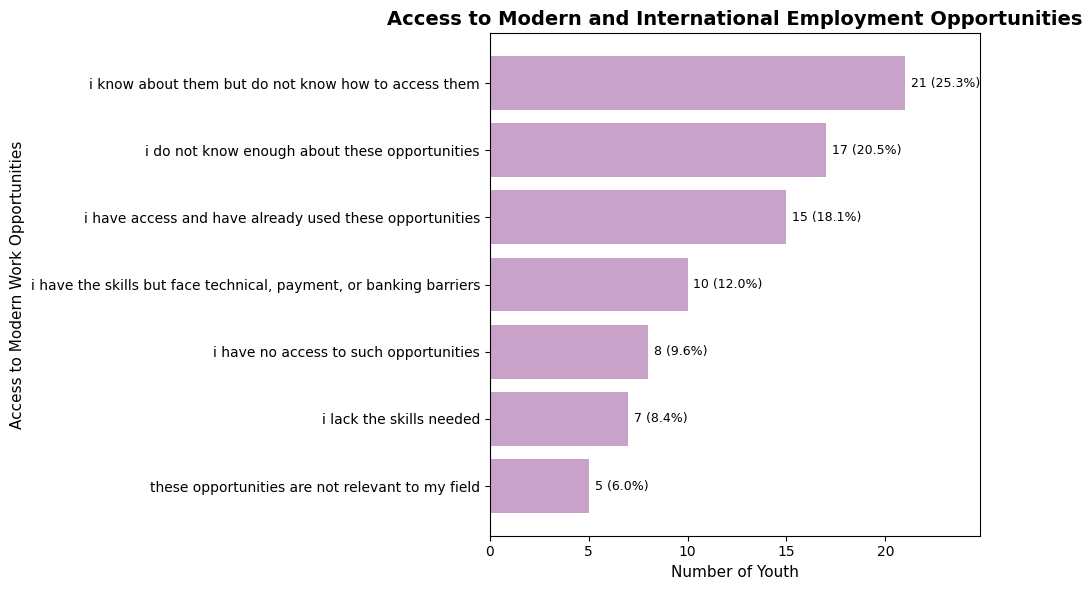

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# ACCESS TO MODERN WORK OPPORTUNITIES
# =========================================================

feature = 'modern_work_access'

# Frequency table using actual dataset values
modern_counts = (
    df_youth[feature]
    .value_counts(dropna=False)
)

modern_percentages = (
    df_youth[feature]
    .value_counts(dropna=False, normalize=True) * 100
)

modern_table = pd.DataFrame({
    'Count': modern_counts,
    'Percentage': modern_percentages.round(1)
})

print("ACCESS TO MODERN WORK OPPORTUNITIES — FREQUENCY TABLE")
print(modern_table)

print("\nTotal:", modern_table['Count'].sum())
print("Percentage:", modern_table['Percentage'].sum())

# =========================================================
# CHART
# =========================================================

plot_data = df_youth[feature].dropna()

modern_counts = plot_data.value_counts()
modern_percentages = modern_counts / len(plot_data) * 100

# Reverse for horizontal bar chart
modern_counts = modern_counts.iloc[::-1]
modern_percentages = modern_percentages.iloc[::-1]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    modern_counts.index.astype(str),
    modern_counts.values,
    color='#C8A2C8'
)

plt.title(
    'Access to Modern and International Employment Opportunities',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Number of Youth', fontsize=11)
plt.ylabel('Access to Modern Work Opportunities', fontsize=11)

for bar, percentage in zip(bars, modern_percentages):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

plt.xlim(
    0,
    max(modern_counts.max() * 1.18, 1)
)

plt.tight_layout()

plt.savefig(
    'figures/youth_modern_work_access.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

PREFERENCES REGARDING EMPLOYMENT ABROAD — FREQUENCY TABLE
                                                   Count  Percentage
work_abroad_preference                                              
move abroad permanently                               34        41.0
work abroad temporarily and return later              25        30.1
stay if i can find a suitable opportunity locally     13        15.7
stay in lebanon                                        5         6.0
i am undecided                                         5         6.0
i would not consider working abroad                    1         1.2

Total: 83
Percentage: 100.0


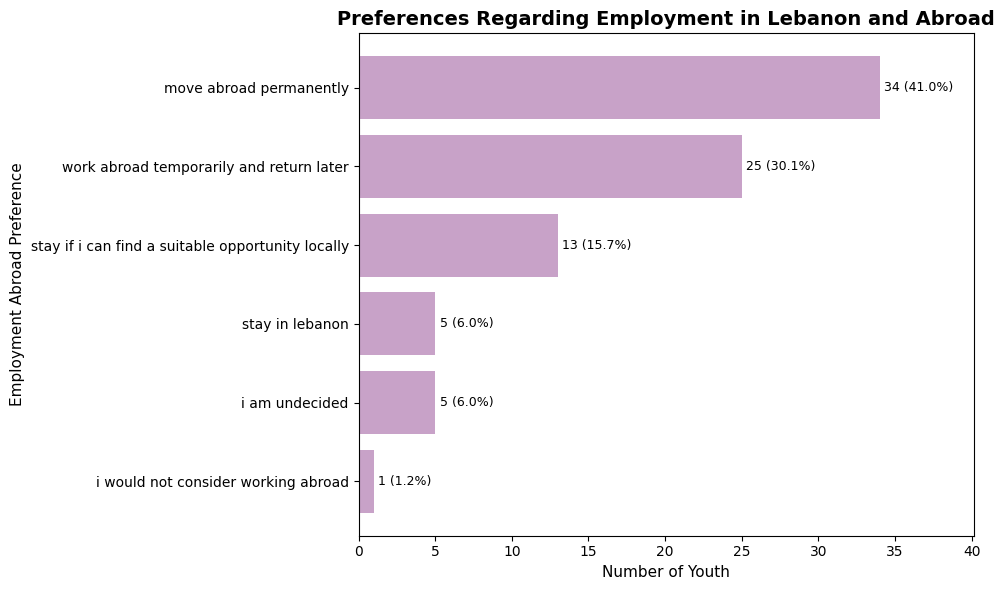

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# PREFERENCES REGARDING EMPLOYMENT ABROAD
# =========================================================

feature = 'work_abroad_preference'

# Frequency table using actual dataset values
abroad_counts = (
    df_youth[feature]
    .value_counts(dropna=False)
)

abroad_percentages = (
    df_youth[feature]
    .value_counts(dropna=False, normalize=True) * 100
)

abroad_table = pd.DataFrame({
    'Count': abroad_counts,
    'Percentage': abroad_percentages.round(1)
})

print("PREFERENCES REGARDING EMPLOYMENT ABROAD — FREQUENCY TABLE")
print(abroad_table)

print("\nTotal:", abroad_table['Count'].sum())
print("Percentage:", abroad_table['Percentage'].sum())

# =========================================================
# CHART
# =========================================================

plot_data = df_youth[feature].dropna()

abroad_counts = plot_data.value_counts()
abroad_percentages = abroad_counts / len(plot_data) * 100

# Reverse for horizontal bar chart
abroad_counts = abroad_counts.iloc[::-1]
abroad_percentages = abroad_percentages.iloc[::-1]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    abroad_counts.index.astype(str),
    abroad_counts.values,
    color='#C8A2C8'
)

plt.title(
    'Preferences Regarding Employment in Lebanon and Abroad',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Number of Youth', fontsize=11)
plt.ylabel('Employment Abroad Preference', fontsize=11)

for bar, percentage in zip(bars, abroad_percentages):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

plt.xlim(
    0,
    max(abroad_counts.max() * 1.18, 1)
)

plt.tight_layout()

plt.savefig(
    'figures/youth_abroad_preferences.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

REASONS FOR CONSIDERING EMPLOYMENT ABROAD — FREQUENCY TABLE
                                           Count  Percentage
                                               1         1.2
Other                                          3         3.6
Professional development                      33        39.8
Lack of suitable opportunities in lebanon     33        39.8
Security stability                            36        43.4
More opportunities related to my field        37        44.6
Greater job stability                         38        45.8
Better working conditions                     42        50.6
Economic conditions in lebanon                46        55.4
Better career opportunities                   56        67.5
Higher salary                                 64        77.1

Total respondents: 83


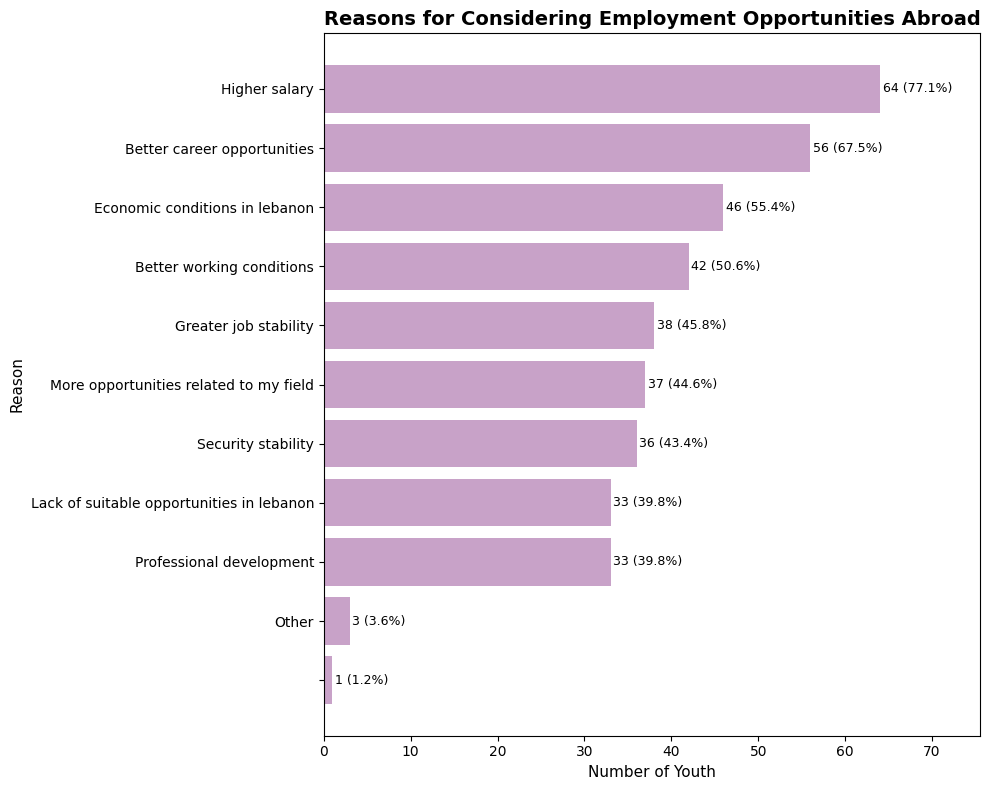

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# REASONS FOR CONSIDERING EMPLOYMENT ABROAD
# =========================================================

reason_columns = [
    col for col in df_youth.columns
    if col.startswith('reasons_work_abroad__')
]

reason_counts = (
    df_youth[reason_columns]
    .sum()
    .fillna(0)
    .sort_values()
)

reason_labels = {
    col: col.replace(
        'reasons_work_abroad__',
        ''
    ).replace('_', ' ').capitalize()
    for col in reason_columns
}

reason_counts.index = reason_counts.index.map(reason_labels)

reason_percentages = (
    reason_counts / len(df_youth) * 100
)

reason_table = pd.DataFrame({
    'Count': reason_counts.astype(int),
    'Percentage': reason_percentages.round(1)
})

print("REASONS FOR CONSIDERING EMPLOYMENT ABROAD — FREQUENCY TABLE")
print(reason_table)

print("\nTotal respondents:", len(df_youth))

# =========================================================
# CHART
# =========================================================

plt.figure(figsize=(10, 8))

bars = plt.barh(
    reason_counts.index,
    reason_counts.values,
    color='#C8A2C8'
)

plt.title(
    'Reasons for Considering Employment Opportunities Abroad',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Number of Youth', fontsize=11)
plt.ylabel('Reason', fontsize=11)

for bar, percentage in zip(bars, reason_percentages):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

plt.xlim(
    0,
    max(reason_counts.max() * 1.18, 1)
)

plt.tight_layout()

plt.savefig(
    'figures/youth_abroad_reasons.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

MOST VALUABLE FORMS OF EMPLOYMENT SUPPORT — FREQUENCY TABLE
                                           Count  Percentage
Entrepreneurship support                       3         3.6
Job matching services                          4         4.8
Professional certifications                    6         7.2
Financial support during job searching         6         7.2
Soft skills training                           6         7.2
Apprenticeships workplace training             7         8.4
Career guidance                                8         9.6
Mentorship from professionals                  9        10.8
Transportation support                        13        15.7
Digital skills training                       13        15.7
Cv application support                        14        16.9
English language training                     14        16.9
Interview preparation                         14        16.9
Networking opportunities with employers       17        20.5
Technical job specific sk

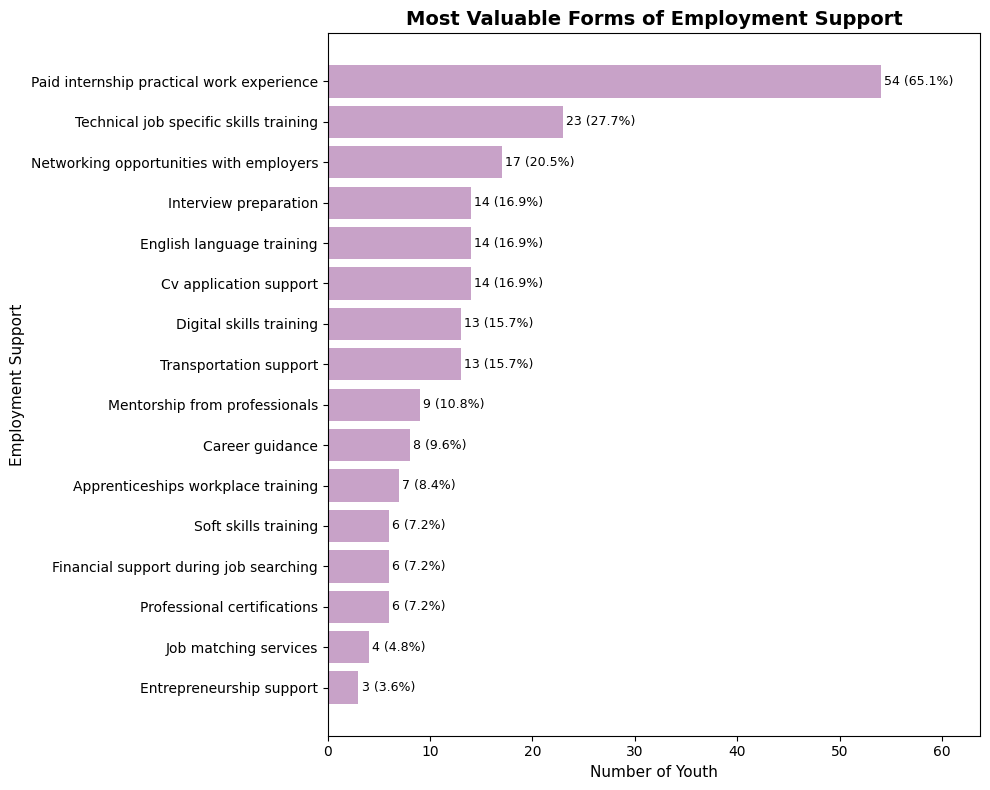

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Select all employment support multiple-response columns
support_columns = [
    col for col in df_youth.columns
    if col.startswith('employment_support__')
]

# Count selections
support_counts = (
    df_youth[support_columns]
    .sum()
    .fillna(0)
    .sort_values()
)

# Create readable labels from the actual column names
support_labels = {
    col: col.replace(
        'employment_support__',
        ''
    ).replace('_', ' ').capitalize()
    for col in support_columns
}

support_counts.index = support_counts.index.map(support_labels)

# Percentages based on all respondents
support_percentages = (
    support_counts / len(df_youth) * 100
)

# Frequency table
support_table = pd.DataFrame({
    'Count': support_counts.astype(int),
    'Percentage': support_percentages.round(1)
})

print("MOST VALUABLE FORMS OF EMPLOYMENT SUPPORT — FREQUENCY TABLE")
print(support_table)

print("\nTotal respondents:", len(df_youth))

# Plot
plt.figure(figsize=(10, 8))

bars = plt.barh(
    support_counts.index,
    support_counts.values,
    color='#C8A2C8'
)

plt.title(
    'Most Valuable Forms of Employment Support',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Number of Youth',
    fontsize=11
)

plt.ylabel(
    'Employment Support',
    fontsize=11
)

# Add count and percentage labels
for bar, percentage in zip(
    bars,
    support_percentages
):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

plt.xlim(
    0,
    max(support_counts.max() * 1.18, 1)
)

plt.tight_layout()

plt.savefig(
    'figures/youth_support_priorities.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

MOST VALUABLE EMPLOYMENT SERVICE — FREQUENCY TABLE
                                    Count  Percentage
most_valuable_service                                
paid internship or work experience     48        57.8
career guidance and job matching        6         7.2
english / language training             6         7.2
networking directly with employers      5         6.0
freelancing / remote-work training      4         4.8
job-specific skills training            3         3.6
other                                   3         3.6
professional certification              3         3.6
entrepreneurship support                2         2.4
interview preparation                   2         2.4
mentorship                              1         1.2

Total: 83
Percentage: 99.80000000000003


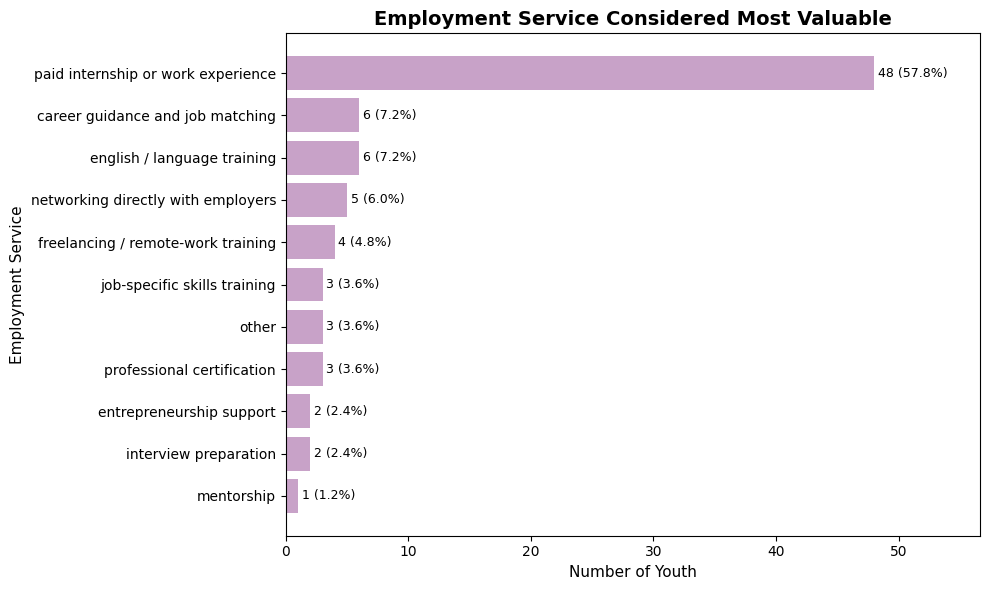

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

feature = 'most_valuable_service'

service_counts = (
    df_youth[feature]
    .value_counts(dropna=False)
)

service_percentages = (
    df_youth[feature]
    .value_counts(dropna=False, normalize=True) * 100
)

service_table = pd.DataFrame({
    'Count': service_counts,
    'Percentage': service_percentages.round(1)
})

print("MOST VALUABLE EMPLOYMENT SERVICE — FREQUENCY TABLE")
print(service_table)

print("\nTotal:", service_table['Count'].sum())
print("Percentage:", service_table['Percentage'].sum())

# Plot
plot_data = df_youth[feature].dropna()

service_counts = plot_data.value_counts()
service_percentages = service_counts / len(plot_data) * 100

service_counts = service_counts.iloc[::-1]
service_percentages = service_percentages.iloc[::-1]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    service_counts.index.astype(str),
    service_counts.values,
    color='#C8A2C8'
)

plt.title(
    'Employment Service Considered Most Valuable',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Number of Youth', fontsize=11)
plt.ylabel('Employment Service', fontsize=11)

for bar, percentage in zip(bars, service_percentages):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())} ({percentage:.1f}%)',
        va='center',
        fontsize=9
    )

plt.xlim(
    0,
    max(service_counts.max() * 1.18, 1)
)

plt.tight_layout()

plt.savefig(
    'figures/youth_priority_service.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [55]:
responses = df_youth['needed_systemic_change'].dropna()

print("Number of responses:", len(responses))
print("\nOPEN-ENDED RESPONSES:")
for i, response in enumerate(responses, 1):
    print(f"{i}. {response}")
    

Number of responses: 61

OPEN-ENDED RESPONSES:
1. More accessible entry-level jobs and paid internships that help young people gain real experience and build stable careers.
2. In my opinion, a chance to get an Internship is enough to help people get a job
3. .
4. Just for it to be easier to find something immediately for a fresh graduate, and for the pay to be logical enough for you to go to work and come back home with food on your plate and still have money on the side for the future.
5. المهارات
6. توفير فرص عمل أكثر للشباب برواتب عادلة واستقرار وظيفي، مع إتاحة التدريب العملي وفرص التطور المهني.
7. Discrimination between nationalities, and giving opportunities to people with less experience because if they never get an opportunity they won't gain any experience
8. The biggest change would be creating more decent and sustainable job opportunities for young people in Lebanon, with fair salaries, career growth, and better connections between education and the actual needs of the job m


1. EDUCATION LEVEL × EMPLOYMENT PREPAREDNESS

COUNTS:
education_job_preparation              i have not received relevant education or training  \
education_level                                                                             
bachelor’s degree                                                                      3    
doctorate / phd                                                                        0    
master’s degree                                                                        1    
professional or online certificate(s)                                                  0    
technical / vocational education                                                       1    

education_job_preparation              moderately  not at all  slightly  \
education_level                                                           
bachelor’s degree                              18           4        15   
doctorate / phd                                 1           0       

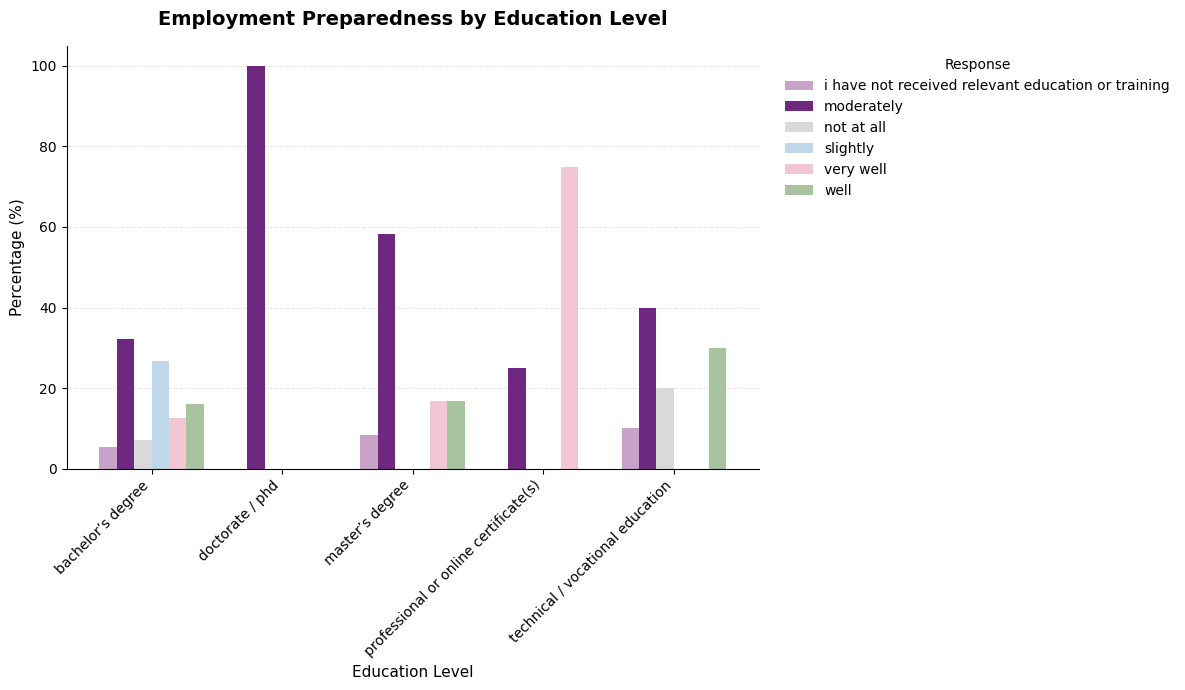

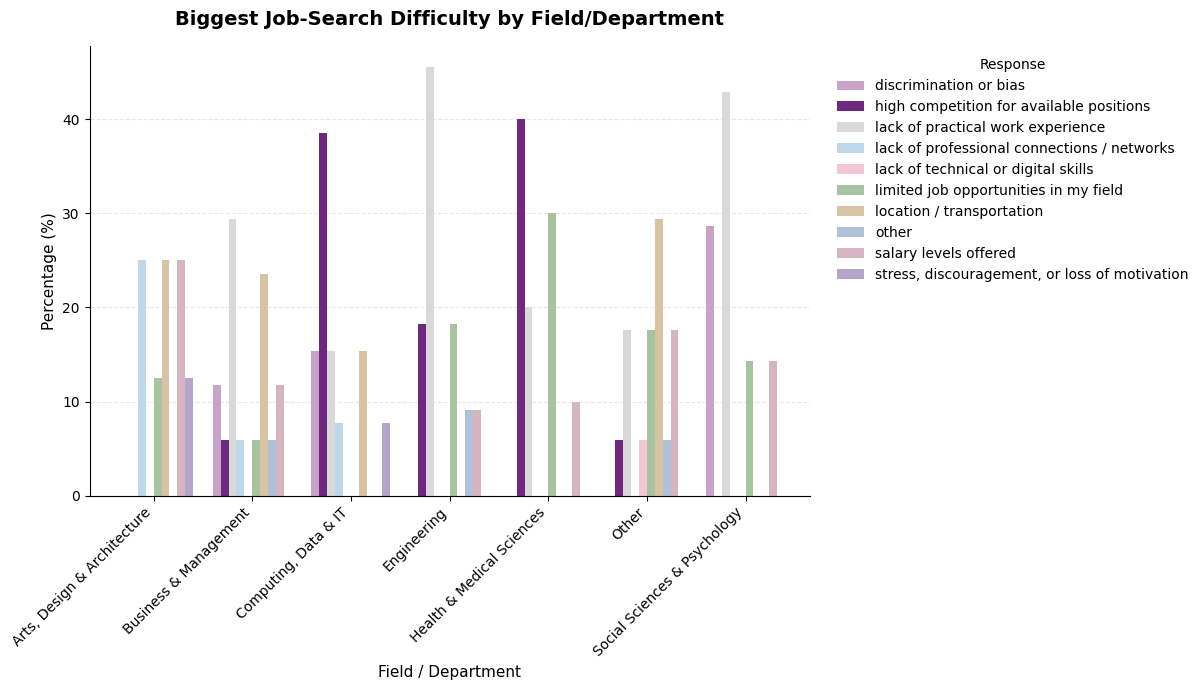

C:\Users\User\AppData\Local\Temp\ipykernel_7440\751335794.py:454: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


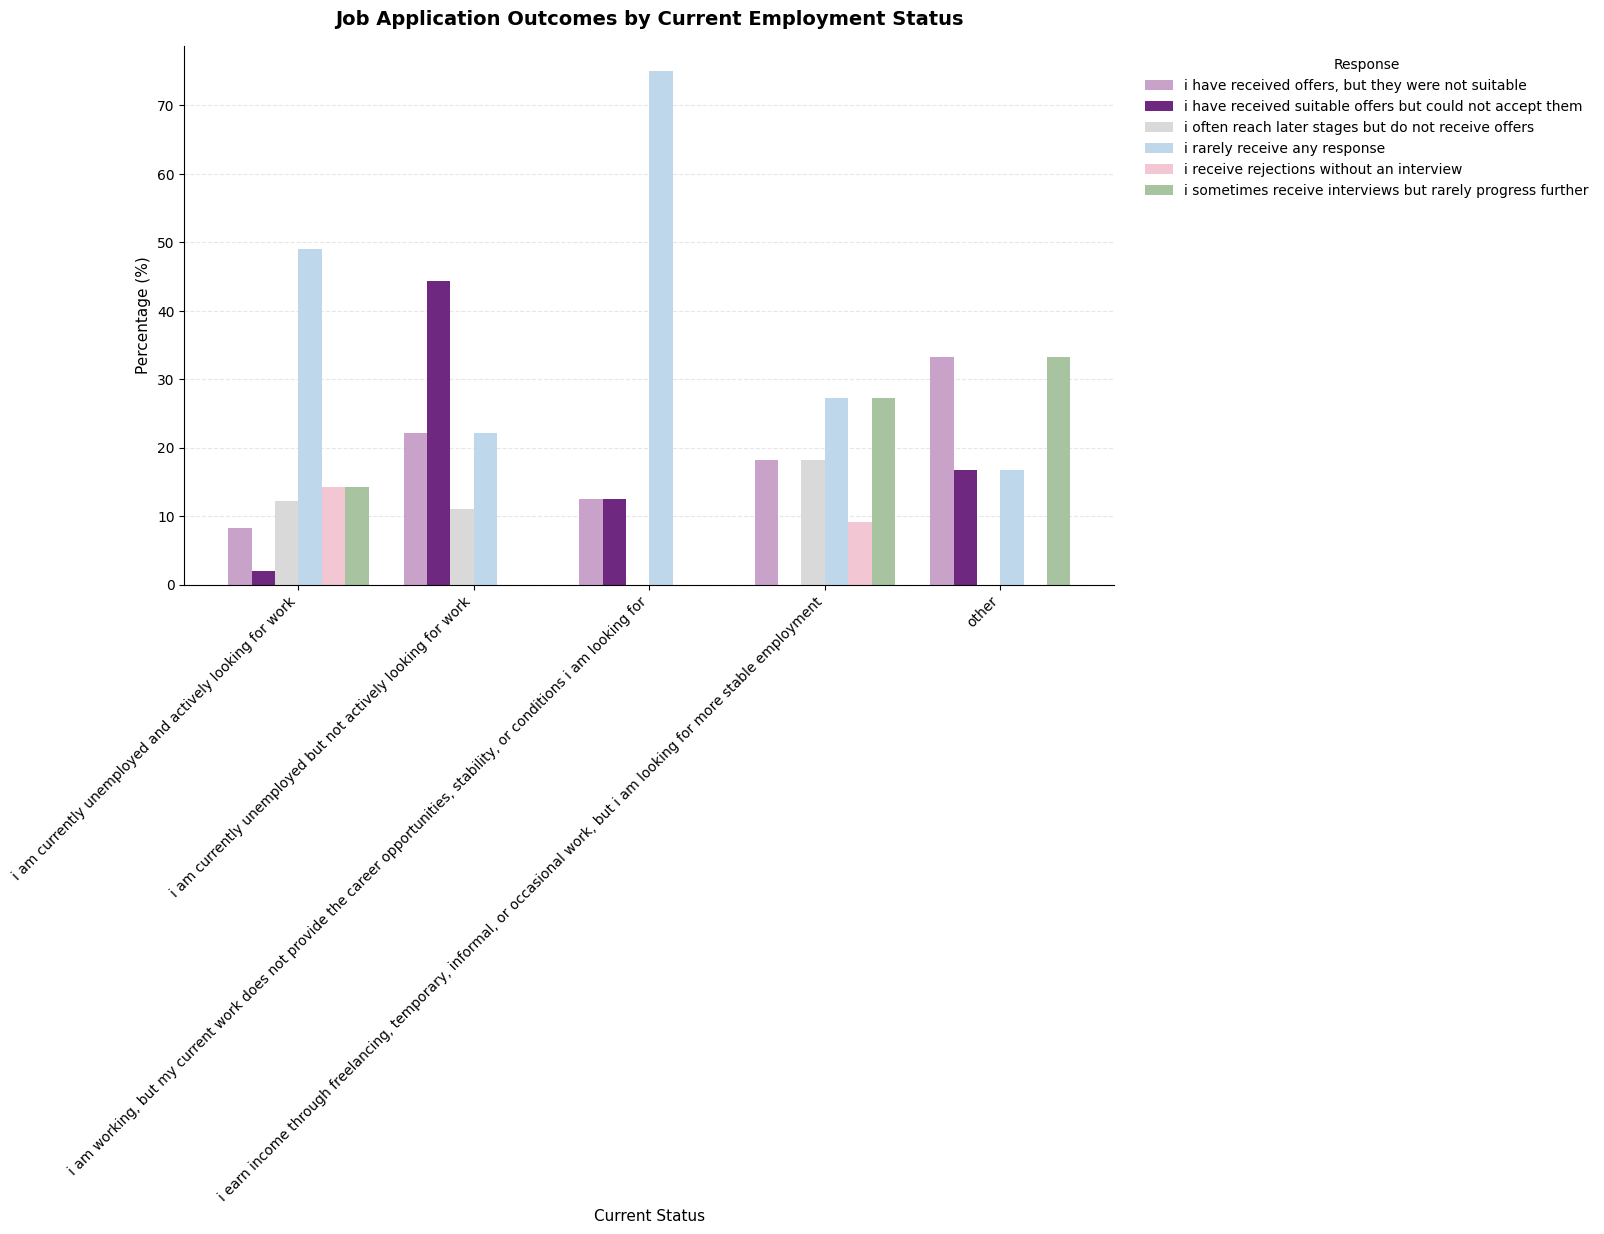

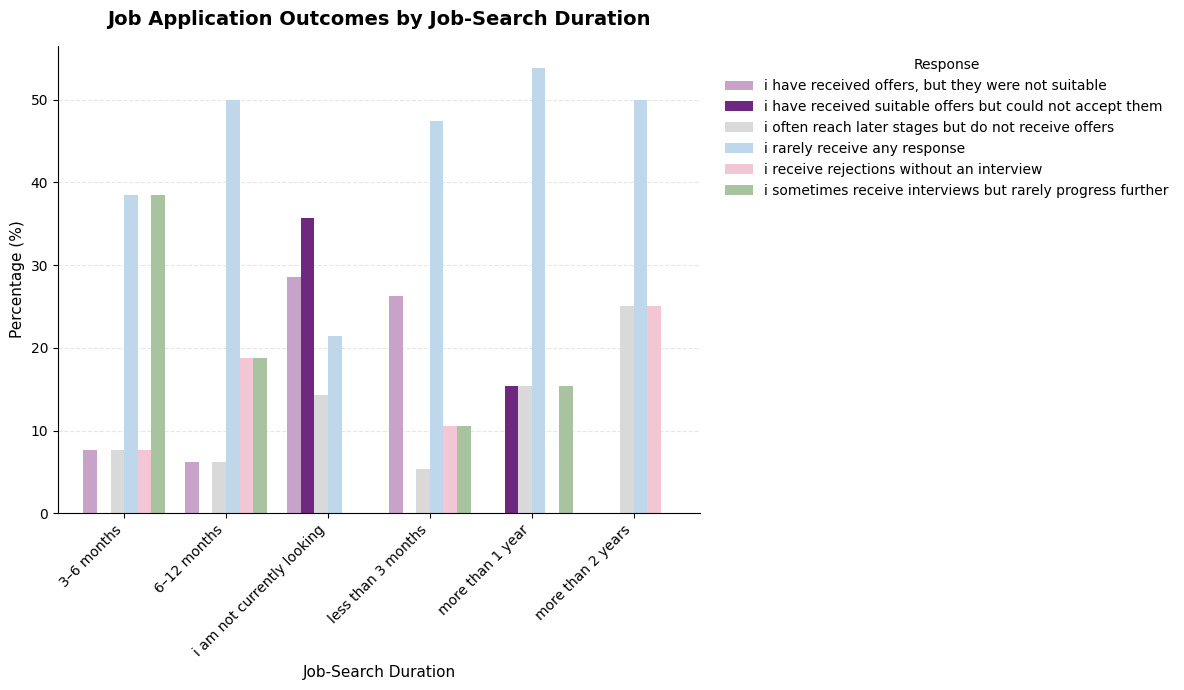

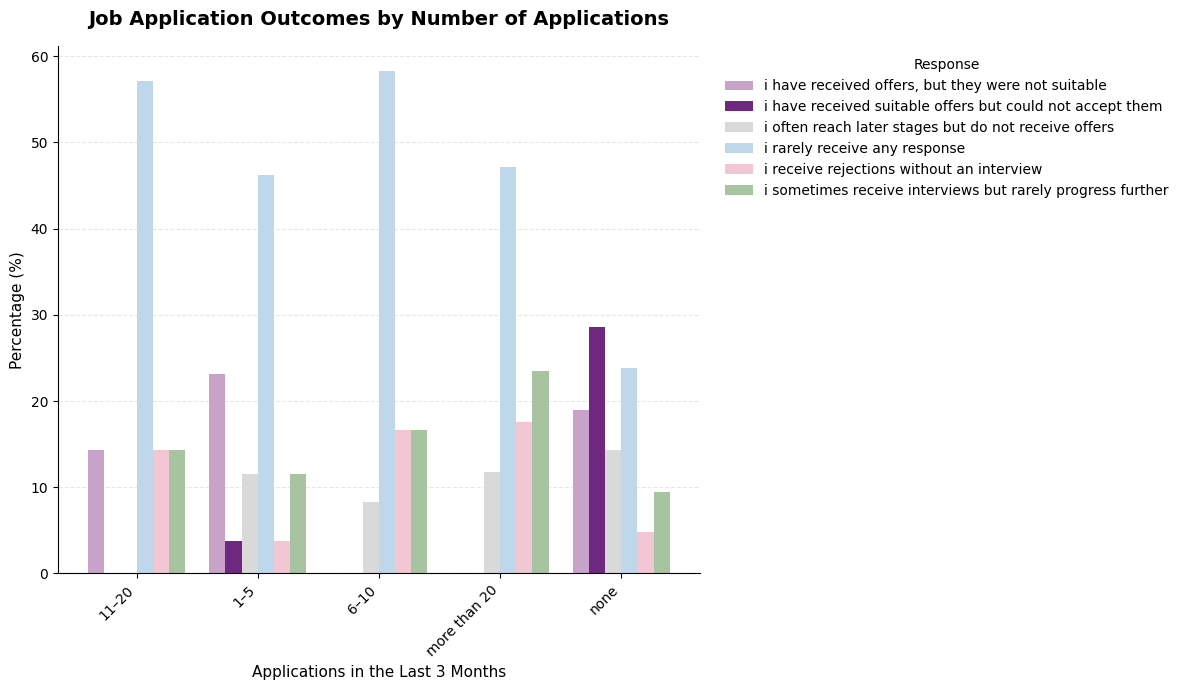

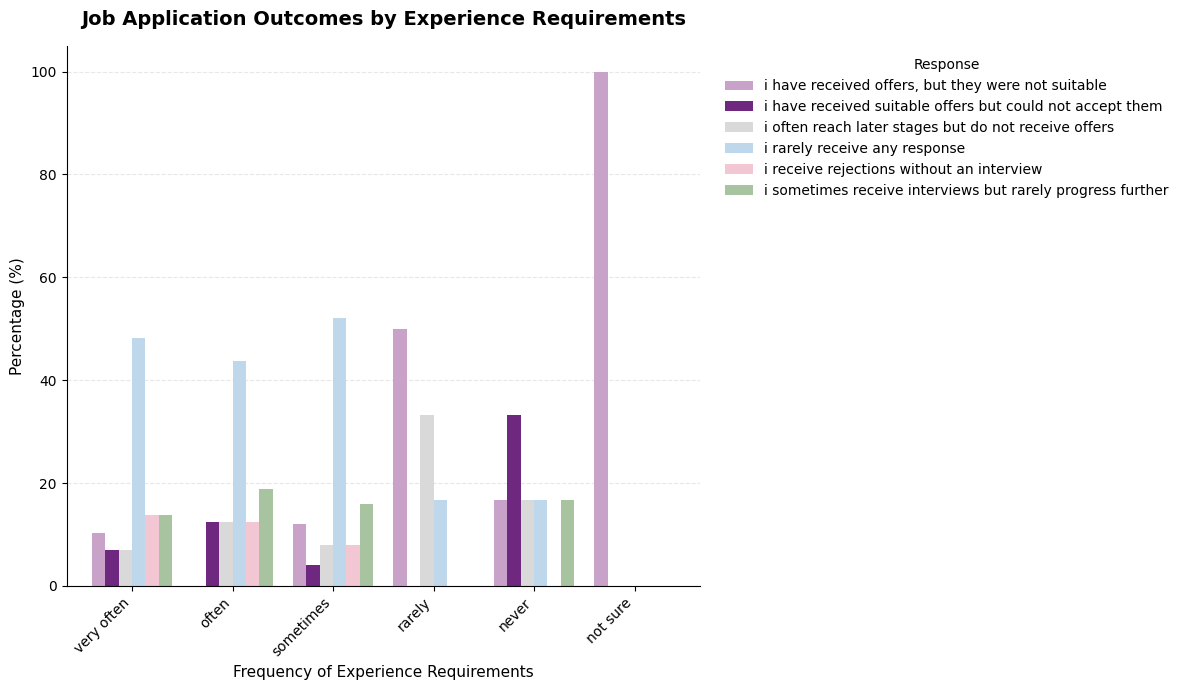

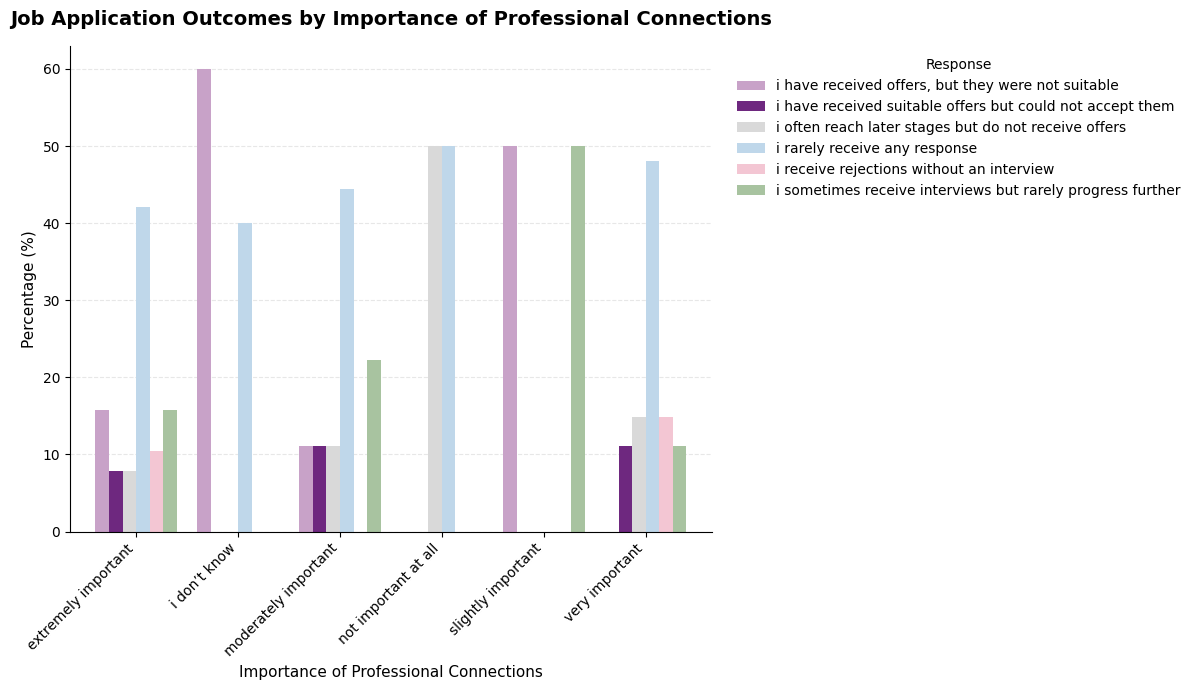

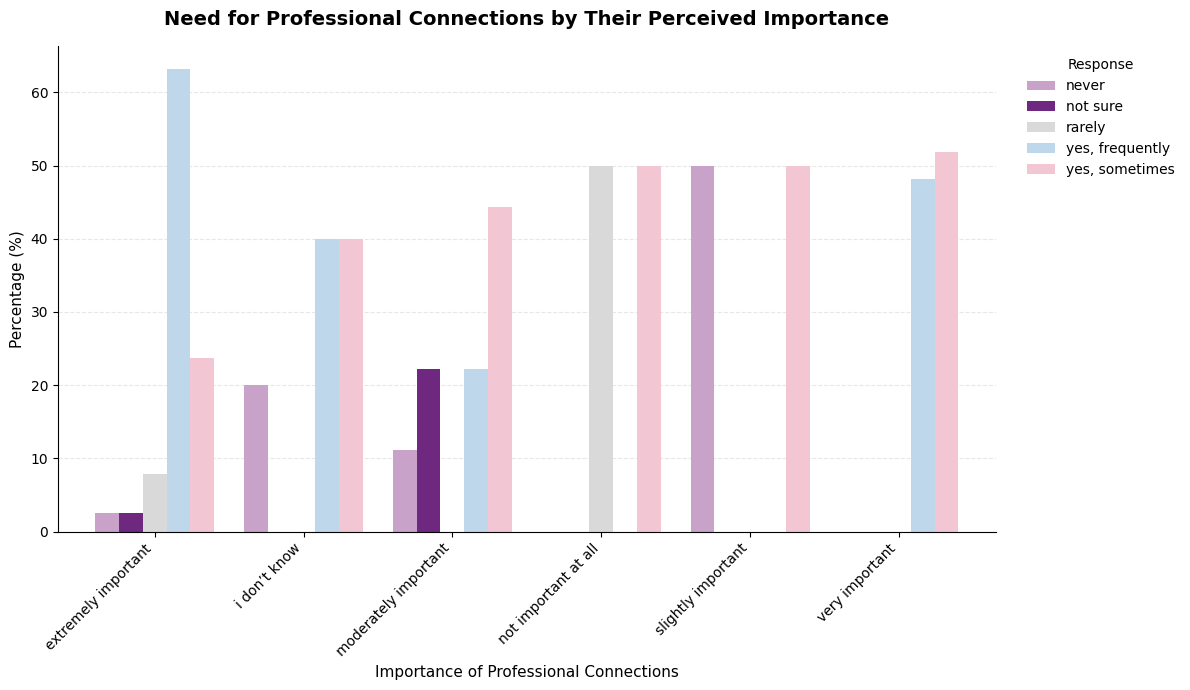


DESCRIPTIVE COMPARISON ANALYSIS COMPLETED
Excel file: youth_group_comparisons.xlsx
Charts saved in: figures/
Main colors:
  - Light purple
  - Deep purple
  - Grey
  - Light blue
  - Light pink
Additional colors are automatically added when needed.


In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ============================================================
# DESCRIPTIVE COMPARISONS ACROSS YOUTH GROUPS
# ============================================================

df = df_youth.copy()

# Create figures directory if it does not exist
os.makedirs('figures', exist_ok=True)


# ============================================================
# FUNCTION TO CREATE CROSSTAB WITH COUNTS AND ROW PERCENTAGES
# ============================================================

def crosstab_with_percentages(data, group_var, outcome_var):

    temp = data[[group_var, outcome_var]].dropna()

    # Counts
    counts = pd.crosstab(
        temp[group_var],
        temp[outcome_var]
    )

    # Row percentages
    row_percentages = (
        pd.crosstab(
            temp[group_var],
            temp[outcome_var],
            normalize='index'
        ) * 100
    ).round(1)

    return counts, row_percentages


# ============================================================
# 1. EDUCATION LEVEL → EMPLOYMENT PREPAREDNESS
# ============================================================

counts_1, pct_1 = crosstab_with_percentages(
    df,
    'education_level',
    'education_job_preparation'
)

print("\n" + "=" * 100)
print("1. EDUCATION LEVEL × EMPLOYMENT PREPAREDNESS")
print("=" * 100)

print("\nCOUNTS:")
print(counts_1)

print("\nROW PERCENTAGES:")
print(pct_1)


# ============================================================
# 2. FIELD/DEPARTMENT → BIGGEST JOB-SEARCH DIFFICULTY
# ============================================================

counts_2, pct_2 = crosstab_with_percentages(
    df,
    'field_department',
    'biggest_difficulty'
)

print("\n" + "=" * 100)
print("2. FIELD/DEPARTMENT × BIGGEST JOB-SEARCH DIFFICULTY")
print("=" * 100)

print("\nCOUNTS:")
print(counts_2)

print("\nROW PERCENTAGES:")
print(pct_2)


# ============================================================
# 3. CURRENT STATUS → APPLICATION OUTCOMES
# ============================================================

counts_3, pct_3 = crosstab_with_percentages(
    df,
    'current_status',
    'application_outcome'
)

print("\n" + "=" * 100)
print("3. CURRENT STATUS × APPLICATION OUTCOME")
print("=" * 100)

print("\nCOUNTS:")
print(counts_3)

print("\nROW PERCENTAGES:")
print(pct_3)


# ============================================================
# 4. JOB-SEARCH DURATION → APPLICATION OUTCOMES
# ============================================================

counts_4, pct_4 = crosstab_with_percentages(
    df,
    'job_search_duration',
    'application_outcome'
)

print("\n" + "=" * 100)
print("4. JOB-SEARCH DURATION × APPLICATION OUTCOME")
print("=" * 100)

print("\nCOUNTS:")
print(counts_4)

print("\nROW PERCENTAGES:")
print(pct_4)


# ============================================================
# 5. NUMBER OF APPLICATIONS → APPLICATION OUTCOMES
# ============================================================

counts_5, pct_5 = crosstab_with_percentages(
    df,
    'applications_3m',
    'application_outcome'
)

print("\n" + "=" * 100)
print("5. NUMBER OF APPLICATIONS × APPLICATION OUTCOME")
print("=" * 100)

print("\nCOUNTS:")
print(counts_5)

print("\nROW PERCENTAGES:")
print(pct_5)


# ============================================================
# 6. EXPERIENCE REQUIREMENTS → APPLICATION OUTCOMES
# ============================================================

counts_6, pct_6 = crosstab_with_percentages(
    df,
    'experience_requirement',
    'application_outcome'
)

print("\n" + "=" * 100)
print("6. EXPERIENCE REQUIREMENTS × APPLICATION OUTCOME")
print("=" * 100)

print("\nCOUNTS:")
print(counts_6)

print("\nROW PERCENTAGES:")
print(pct_6)


# ============================================================
# 7. IMPORTANCE OF CONNECTIONS → APPLICATION OUTCOMES
# ============================================================

counts_7, pct_7 = crosstab_with_percentages(
    df,
    'importance_connections',
    'application_outcome'
)

print("\n" + "=" * 100)
print("7. IMPORTANCE OF PROFESSIONAL CONNECTIONS × APPLICATION OUTCOME")
print("=" * 100)

print("\nCOUNTS:")
print(counts_7)

print("\nROW PERCENTAGES:")
print(pct_7)


# ============================================================
# 8. IMPORTANCE OF CONNECTIONS → WHETHER CONNECTIONS ARE NEEDED
# ============================================================

counts_8, pct_8 = crosstab_with_percentages(
    df,
    'importance_connections',
    'needed_connection'
)

print("\n" + "=" * 100)
print("8. IMPORTANCE OF PROFESSIONAL CONNECTIONS × NEED FOR CONNECTIONS")
print("=" * 100)

print("\nCOUNTS:")
print(counts_8)

print("\nROW PERCENTAGES:")
print(pct_8)


# ============================================================
# 9. EMPLOYMENT PREPAREDNESS → MISSING SKILLS
# ============================================================

counts_9, pct_9 = crosstab_with_percentages(
    df,
    'education_job_preparation',
    'missing_skills'
)

print("\n" + "=" * 100)
print("9. EMPLOYMENT PREPAREDNESS × MISSING SKILLS")
print("=" * 100)

print("\nCOUNTS:")
print(counts_9)

print("\nROW PERCENTAGES:")
print(pct_9)


# ============================================================
# SAVE ALL RESULTS IN ONE EXCEL FILE
# ============================================================

comparisons = {
    'education_preparedness': (counts_1, pct_1),
    'field_difficulty': (counts_2, pct_2),
    'status_outcome': (counts_3, pct_3),
    'duration_outcome': (counts_4, pct_4),
    'applications_outcome': (counts_5, pct_5),
    'experience_outcome': (counts_6, pct_6),
    'connections_outcome': (counts_7, pct_7),
    'connections_needed': (counts_8, pct_8),
    'preparedness_skills': (counts_9, pct_9)
}

with pd.ExcelWriter(
    'youth_group_comparisons.xlsx',
    engine='openpyxl'
) as writer:

    for name, (counts, percentages) in comparisons.items():

        counts.to_excel(
            writer,
            sheet_name=f'{name[:25]}_counts'
        )

        percentages.to_excel(
            writer,
            sheet_name=f'{name[:22]}_pct'
        )

print("\nAll comparison tables saved to:")
print("youth_group_comparisons.xlsx")


# ============================================================
# REPORT COLOR PALETTE
# ============================================================
#
# Main report colors:
#   1. Light purple
#   2. Deep purple
#   3. Grey
#   4. Light blue
#   5. Light pink
#
# Additional compatible colors are used ONLY when a chart
# contains more than five response categories.
# ============================================================

REPORT_COLORS = [
    '#C8A2C8',  # Light purple
    '#6E287F',  # Deep purple
    '#D9D9D9',  # Grey
    '#BFD7EA',  # Light blue
    '#F3C6D3',  # Light pink
]


# ============================================================
# ADDITIONAL COMPATIBLE COLORS
# ============================================================
#
# These are muted colors that remain visually compatible
# with the main purple / grey / blue / pink report palette.
#
# They are ONLY used when more than five categories exist.
# ============================================================

ADDITIONAL_COLORS = [
    '#A8C3A0',  # Muted sage green
    '#D8C3A5',  # Muted beige
    '#AFC1D6',  # Muted steel blue
    '#D6B4C2',  # Muted dusty rose
    '#B5A6C9',  # Muted lavender
    '#C4B7A6',  # Muted taupe
    '#9FB8AD',  # Muted green-grey
    '#C5B4D6',  # Soft violet
    '#B8C9D9',  # Soft blue-grey
    '#D7C4B8',  # Soft warm beige
]


# ============================================================
# FUNCTION TO GENERATE UNIQUE COLORS FOR EACH CHART
# ============================================================

def get_chart_colors(n_categories):

    # Combine main colors with additional compatible colors
    all_colors = REPORT_COLORS + ADDITIONAL_COLORS

    # Make sure there are enough colors
    if n_categories > len(all_colors):
        raise ValueError(
            f"The chart contains {n_categories} categories, "
            f"but only {len(all_colors)} compatible colors "
            f"are available."
        )

    # Return exactly the number of colors needed
    return all_colors[:n_categories]


# ============================================================
# FUNCTION TO GENERATE DESCRIPTIVE COMPARISON CHARTS
# ============================================================

def plot_comparison(
    percentages,
    title,
    xlabel,
    filename
):

    # Copy data to avoid modifying the original table
    plot_data = percentages.copy()

    # Number of response categories
    n_categories = len(plot_data.columns)

    # --------------------------------------------------------
    # Get unique colors
    # --------------------------------------------------------

    colors = get_chart_colors(n_categories)

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(12, 7)
    )

    # --------------------------------------------------------
    # Plot grouped bars
    # --------------------------------------------------------

    plot_data.plot(
        kind='bar',
        ax=ax,
        color=colors,
        width=0.80
    )

    # --------------------------------------------------------
    # Title
    # --------------------------------------------------------

    ax.set_title(
        title,
        fontsize=14,
        fontweight='bold',
        pad=15
    )

    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------

    ax.set_xlabel(
        xlabel,
        fontsize=11
    )

    ax.set_ylabel(
        'Percentage (%)',
        fontsize=11
    )

    # --------------------------------------------------------
    # X-axis
    # --------------------------------------------------------

    plt.xticks(
        rotation=45,
        ha='right'
    )

    # --------------------------------------------------------
    # Y-axis
    # --------------------------------------------------------

    ax.set_ylim(
        bottom=0
    )

    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.3
    )

    ax.set_axisbelow(True)

    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    ax.legend(
        title='Response',
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        frameon=False
    )

    # --------------------------------------------------------
    # Remove unnecessary borders
    # --------------------------------------------------------

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # --------------------------------------------------------
    # Layout
    # --------------------------------------------------------

    plt.tight_layout()

    # --------------------------------------------------------
    # Save chart
    # --------------------------------------------------------

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()


# ============================================================
# MAIN REPORT CHARTS
# ============================================================


# ------------------------------------------------------------
# 1. Education Level × Employment Preparedness
# ------------------------------------------------------------

plot_comparison(
    pct_1,
    'Employment Preparedness by Education Level',
    'Education Level',
    'figures/education_preparedness_comparison.png'
)


# ------------------------------------------------------------
# 2. Field/Department × Biggest Difficulty
# ------------------------------------------------------------

plot_comparison(
    pct_2,
    'Biggest Job-Search Difficulty by Field/Department',
    'Field / Department',
    'figures/field_department_difficulty_comparison.png'
)


# ------------------------------------------------------------
# 3. Current Status × Application Outcome
# ------------------------------------------------------------

plot_comparison(
    pct_3,
    'Job Application Outcomes by Current Employment Status',
    'Current Status',
    'figures/status_application_outcome_comparison.png'
)


# ------------------------------------------------------------
# 4. Job-Search Duration × Application Outcome
# ------------------------------------------------------------

plot_comparison(
    pct_4,
    'Job Application Outcomes by Job-Search Duration',
    'Job-Search Duration',
    'figures/search_duration_application_outcome.png'
)


# ------------------------------------------------------------
# 5. Number of Applications × Application Outcome
# ------------------------------------------------------------

plot_comparison(
    pct_5,
    'Job Application Outcomes by Number of Applications',
    'Applications in the Last 3 Months',
    'figures/applications_application_outcome.png'
)


# ------------------------------------------------------------
# 6. Experience Requirements × Application Outcome
# ------------------------------------------------------------

plot_comparison(
    pct_6,
    'Job Application Outcomes by Experience Requirements',
    'Frequency of Experience Requirements',
    'figures/experience_application_outcome.png'
)


# ------------------------------------------------------------
# 7. Importance of Connections × Application Outcome
# ------------------------------------------------------------

plot_comparison(
    pct_7,
    'Job Application Outcomes by Importance of Professional Connections',
    'Importance of Professional Connections',
    'figures/connections_application_outcome.png'
)


# ------------------------------------------------------------
# 8. Importance of Connections × Need for Connections
# ------------------------------------------------------------

plot_comparison(
    pct_8,
    'Need for Professional Connections by Their Perceived Importance',
    'Importance of Professional Connections',
    'figures/connections_needed_comparison.png'
)


# ============================================================
# COMPLETION MESSAGE
# ============================================================

print("\n" + "=" * 80)
print("DESCRIPTIVE COMPARISON ANALYSIS COMPLETED")
print("=" * 80)
print("Excel file: youth_group_comparisons.xlsx")
print("Charts saved in: figures/")
print("Main colors:")
print("  - Light purple")
print("  - Deep purple")
print("  - Grey")
print("  - Light blue")
print("  - Light pink")
print("Additional colors are automatically added when needed.")
print("=" * 80)